# Метод фон Цейпеля

Метод фон Цейпеля - асимптотический метод теории возмущений, предназначенный для интегрирования канонических систем уравнений Гамильтона [von Zeipel, 1916]. Его цель заключается в последовательном исключении циклических (быстрых) угловых переменных из функции Гамильтона с помощью канонических преобразований. Данные преобразования задаются производящей функцией смешанного типа, зависящей от старых координат и новых импульсов.

Базисом для построения асимптотических рядов фон Цейпеля служит фазовое пространство в канонических переменных «действие-угол» $(I, \theta)$, в котором невозмущенный гамильтониан зависит исключительно от импульсов действия. Ниже рассмотрены математическая структура и алгоритм метода на примере одномерного ангармонического осциллятора.

### Методическое примечание о нотации индексов

Для исключения двусмысленности при изучении асимптотических методов в данном конспекте разделены две качественно различные природы индексных обозначений [Арнольд, 2024; von Zeipel, 1916; Пуанкаре, 1971]:

1. **Геометрические (тензорные) индексы**: Используются для общего описания многомерных канонических пространств в переменных $(q^i, p_i)$ или $(\theta^i, I_i)$. Согласно свойствам кокасательных расслоений, обобщенные координаты и фазовые углы несут верхний контравариантный индекс ($q^i, \theta^i$), а сопряженные им импульсы и действия — нижний ковариантный индекс ($p_i, I_i$) [Новиков, Тайманов, 2005]. *Примечание: Для одномерных модельных систем (Разделы 1–4) с целью упрощения аналитических выложений геометрические индексы опускаются, и переменные записываются как $(q, p)$ или $(\theta, I)$.*
2. **Метки порядка малости теории возмущений**: Записываются строго в верхнем регистре в круглых скобках у символов скалярных потенциалов или вектор-функций. Например, в асимптотическом разложении гамильтониана $H = H^{(0)} + \varepsilon H^{(1)} + \varepsilon^2 H^{(2)}$ или производящей функции $S = S^{(0)} + \varepsilon S^{(1)} + \varepsilon^2 S^{(2)}$ индексы $(0), (1), (2)$ указывают исключительно на порядок степени малого параметра $\varepsilon$, при котором стоит данная функция [Пуанкаре, 1971; Deprit, 1969]. Наличие круглых скобок позволяет однозначно дифференцировать порядок приближения от контравариантных геометрических индексов многомерных координат.

При переходе к прикладным задачам небесной механики и динамики ИСЗ (Разделы 7–9) элементы Делоне $(L, G, H_{\text{Del}}, l, g, h)$ и переменные Хилла $(R, G, H_{\text{Del}}, r, u, h)$ рассматриваются как фиксированный набор скалярных величин и записываются без дополнительных индексов, что соответствует классической астродинамической традиции [Brouwer, 1959; Izsak, 1963].

## 1. Постановка задачи

В качестве исходной модели исследуется гамильтониан одномерного линейного осциллятора с малой кубической ангармонической поправкой к потенциальной энергии [von Zeipel, 1916]:
$$ H(q, p) = \frac{p^2 + q^2}{2} + \varepsilon q^3 \tag{1} $$

где $\varepsilon$ - малый параметр возмущения ($\varepsilon \ll 1$).

Переход к каноническим переменным «действие-угол» для невозмущенной части системы осуществляется с помощью канонического преобразования:
$$ q = \sqrt{2I} \cos\theta, \quad p = -\sqrt{2I} \sin\theta $$

После подстановки данных выражений в (1) на основании тригонометрического тождества $\cos^3\theta = \frac{3}{4}\cos\theta + \frac{1}{4}\cos(3\theta)$, возмущенная функция принимает вид:
$$ H(I, \theta) = I + \varepsilon (2I)^{3/2} \left( \frac{3}{4}\cos\theta + \frac{1}{4}\cos(3\theta) \right) \tag{2} $$

Переменная $\theta$ является быстрой фазой, совершающей полный оборот за период колебания системы. Целью алгоритма является построение канонического преобразования к новым переменным $(\bar{I}, \bar{\theta})$, в которых преобразованный гамильтониан $\bar{H}$ не зависит от фазы $\bar{\theta}$. Данный подход позволяет определить новое действие $\bar{I}$, служащее интегралом движения усредненной системы в первом приближении по малому параметру $\varepsilon$.

### 1.1. Физический смысл переменных «действие-угол»

Колебательные движения описываются через каноническую координату $q$ и канонический импульс $p$. На фазовой плоскости траектория невозмущенного гармонического осциллятора представляет собой окружность, задаваемую законом сохранения энергии:
$$ \frac{p^2 + q^2}{2} = E $$

Переход к переменным «действие-угол» - каноническое преобразование, которое нормализует геометрию фазового пространства, связывая декартовы координаты с полярными на фазовой плоскости через радиус $R = \sqrt{2I}$:
*   Переменная угла $\theta$ определяет фазу колебаний и текущее угловое положение системы на фазовой траектории в диапазоне от $0$ до $2\pi$;
*   Переменная действия $I$ представляет собой канонический импульс, определяющий величину площади фазового портрета, ограниченного замкнутой траекторией [Уиттекер, 1937]:
    $$ I = \frac{1}{2\pi} \oint p \, dq = \frac{E}{\omega_0} $$


Для рассматриваемой системы собственная частота линейных колебаний $\omega_0 = 1$, откуда $I = E$.

В невозмущенной автономной системе уравнения Гамильтона принимают интегрируемый линейный вид [Уиттекер, 1937]:
$$ \frac{dI}{dt} = -\frac{\partial H^{(0)}}{\partial \theta} = 0, \quad \frac{d\theta}{dt} = \frac{\partial H^{(0)}}{\partial I} = 1 \implies \theta = t + \theta_0 \tag{3} $$

Асимптотический алгоритм предназначен для построения в возмущенной нелинейной системе нового действия $\bar{I}$, которое является строгим интегралом движения усредненной системы ($\frac{d\bar{I}}{dt} = 0$), в то время как новый угол $\bar{\theta}$ изменяется равномерно с модифицированной нелинейной частотой: $\frac{d\bar{\theta}}{dt} = \bar{\omega}(\bar{I})$.

## 2. Структура канонического преобразования фон Цейпеля

Для перехода от старых переменных к новым усредненным переменным строится каноническое преобразование. Это преобразование задается производящей функцией смешанного типа $S(\theta, \bar{I}, \varepsilon)$, зависящей от старых угловых координат $\theta$ и новых импульсов действия $\bar{I}$ [von Zeipel, 1916]:
$$ S(\theta, \bar{I}, \varepsilon) = \bar{I} \theta + \varepsilon S^{(1)}(\theta, \bar{I}) + \varepsilon^2 S^{(2)}(\theta, \bar{I}) + O(\varepsilon^3) $$

где первый член $S^{(0)} = \bar{I} \theta$ порождает тождественный переход, а функции $S^{(k)}(\theta, \bar{I})$ являются $2\pi$-периодическими по угловой переменной $\theta$ и описывают короткопериодические возмущения системы.

В соответствии с правилами матричного дифференцирования и зафиксированным координатно-строковым протоколом, связь между исходными и новыми фазовыми переменными определяется дифференциальными соотношениями [Голдстейн, Пул, Сафко, 2012]:
$$ I = \frac{\partial S}{\partial \theta} = \bar{I} + \varepsilon \frac{\partial S^{(1)}}{\partial \theta} + \varepsilon^2 \frac{\partial S^{(2)}}{\partial \theta} + O(\varepsilon^3) \tag{4} $$
$$ \bar{\theta} = \frac{\partial S}{\partial \bar{I}} = \theta + \varepsilon \frac{\partial S^{(1)}}{\partial \bar{I}} + \varepsilon^2 \frac{\partial S^{(2)}}{\partial \bar{I}} + O(\varepsilon^3) \tag{5} $$

Новый преобразованный гамильтониан $\bar{H}(\bar{I}, \varepsilon)$ по условию метода фон Цейпеля должен быть освобожден от явной зависимости от быстрой фазы $\bar{\theta}$, то есть являться функцией исключительно новых импульсов действия:
$$ \bar{H}(\bar{I}, \varepsilon) = \bar{H}^{(0)}(\bar{I}) + \varepsilon \bar{H}^{(1)}(\bar{I}) + \varepsilon^2 \bar{H}^{(2)}(\bar{I}) + O(\varepsilon^3) $$

Связь между исходным и преобразованным гамильтонианами определяется стационарным тождеством Гамильтона-Якоби для автономных систем [Арнольд, 2024]:
$$ H\left(\theta, \frac{\partial S}{\partial \theta}\right) = \bar{H}\left(\bar{I}, \varepsilon\right) \tag{6} $$

### 2.1 Вспомним, что такое производящая функция

Каноничность отображения $(\theta, I) \to (\bar{\theta}, \bar{I})$ гарантируется, если уравнения перехода между старыми и новыми переменными определяются через частные производные скалярной производящей функции [Маркеев, 2024]. Для асимптотических методов теории возмущений применяется производящая функция второго типа $S(\theta, \bar{I}, \varepsilon)$, аргументами которой служат старые координаты (углы) и новые импульсы (действия) [Голдстейн, Пул, Сафко, 2012]:
$$ I = \frac{\partial S}{\partial \theta}, \quad \bar{\theta} = \frac{\partial S}{\partial \bar{I}} $$

#### Пример 1. Тождественное каноническое преобразование

Рассмотрим базовую линейную производящую функцию, задающую тождественный переход в фазовом пространстве:
$$ S^{(0)}(\theta, \bar{I}) = \bar{I} \theta $$

Применение соотношений канонического перехода (4) и (5) приводит к тождествам:
*   Старый канонический импульс: $I = \frac{\partial (\bar{I} \theta)}{\partial \theta} = \bar{I}$
*   Новая каноническая координата: $\bar{\theta} = \frac{\partial (\bar{I} \theta)}{\partial \bar{I}} = \theta$

Функция $S^{(0)} = \bar{I} \theta$ не изменяет метрику фазового пространства и служит невозмущенной основой для построения асимптотических рядов.

#### Пример 2. Канонический сдвиг координат

Рассмотрим деформацию фазовых осей под действием малого постоянного возмущения. Добавим к тождественной производящей функции линейную поправку первого порядка:
$$ S(\theta, \bar{I}, \varepsilon) = \bar{I} \theta + \varepsilon \bar{I} c $$

где $c$ - константа сдвига. Соответствующие соотношения перехода (4) и (5) принимают вид:
*   Старый импульс: $I = \frac{\partial S}{\partial \theta} = \bar{I}$ (переменная действия сохраняет свое значение);
*   Новая координата: $\bar{\theta} = \frac{\partial S}{\partial \bar{I}} = \theta + \varepsilon c$

Из полученного выражения следует классическое линейное соотношение переноса начала отсчета угловой переменной: $\theta = \bar{\theta} - \varepsilon c$.

В методе фон Цейпеля реализуется аналогичный подход. Искомая производящая функция представляется в виде формального степенного ряда (4). Периодические поправки $S^{(k)}(\theta, \bar{I})$ подбираются таким образом, чтобы их частные производные порождали компенсирующие смещения, которые нивелируют влияние нелинейных членов исходного гамильтониана и переводят преобразованную систему к интегрируемому вековому виду [von Zeipel, 1916].



## 3. Нахождение уравнений первого приближения

Для определения аналитической структуры канонического преобразования первого порядка подставим соотношения канонического перехода (4) в исходную функцию Гамильтона и выполним разложение невозмущенной части $H^{(0)}(I)$ в ряд Тейлора в окрестности нового импульса действия $\bar{I}$. Ограничиваясь членами первого порядка малости относительно $\varepsilon$, приравняем полученное функциональное выражение к преобразованному гамильтониану [von Zeipel, 1916]:
$$ \bar{H} = \bar{H}^{(0)} + \varepsilon \bar{H}^{(1)} + O(\varepsilon^2) $$

Продолжая исследование сквозного примера одномерного ангармонического осциллятора, подставим явный вид его невозмущенного гамильтониана $H^{(0)}(I) = I$ и тригонометрический спектр функции возмущения $H^{(1)}(\bar{I}, \theta)$, полученный в разделе 1. Поскольку поправка $H^{(1)}$ изначально входит в уравнение с малым множителем $\varepsilon$, её аргумент действия $I$ в первом приближении заменяется на $\bar{I}$, так как учет поправок к действию порождает члены более высоких порядков малости $O(\varepsilon^2)$ [Пуанкаре, 1971]:
$$ \left(\bar{I} + \varepsilon \frac{\partial S^{(1)}}{\partial \theta}\right) + \varepsilon(2\bar{I})^{3/2}\left(\frac{3}{4}\cos\theta + \frac{1}{4}\cos(3\theta)\right) + O(\varepsilon^2) = \bar{H}^{(0)}(\bar{I}) + \varepsilon \bar{H}^{(1)}(\bar{I}) $$

Расщепление полученного равенства по степеням малого параметра $\varepsilon$ определяет систему зацепляющихся уравнений теории возмущений [Пуанкаре, 1971]:

*   **Порядок $O(1)$** определяет гамильтониан невозмущенной системы в новых переменных:
    $$ \bar{H}^{(0)}(\bar{I}) = \bar{I} $$
*   **Порядок $O(\varepsilon)$** формирует гомологическое уравнение первого порядка, связывающее неизвестную поправку к гамильтониану $\bar{H}^{(1)}$ и частную производную функции по быстрой угловой переменной $\theta$:
    $$ \frac{\partial S^{(1)}}{\partial \theta} + (2\bar{I})^{3/2}\left(\frac{3}{4}\cos\theta + \frac{1}{4}\cos(3\theta)\right) = \bar{H}^{(1)}(\bar{I}) \tag{7} $$


### 3.1. Разделение на среднюю и осциллирующую компоненты

Разделение гомологического уравнения первого порядка (7) на вековую и короткопериодическую составляющие осуществляется с помощью линейного интегрального оператора усреднения по быстрой фазе $\theta$ на замкнутом периоде $[0, 2\pi]$ [von Zeipel, 1916]:
$$ \langle \dots \rangle_\theta = \frac{1}{2\pi} \int_{0}^{2\pi} \dots d\theta $$

*   **Усредненная часть** гомологического уравнения определяет преобразованный гамильтониан первого порядка $\bar{H}^{(1)}$ и содержит члены, инвариантные относительно быстрой фазы. Поскольку среднее значение тригонометрических функций на периоде равно нулю ($\langle \cos\theta \rangle_\theta = 0, \langle \cos(3\theta) \rangle_\theta = 0$), в левой части уравнения (7) постоянные члены отсутствуют. Отсюда поправка первого порядка к усредненному гамильтониану тождественно равна нулю [Пуанкаре, 1971]:
    $$ \bar{H}^{(1)}(\bar{I}) = 0 $$
*   **Осциллирующая часть** гомологического уравнения определяет периодическую поправку к производящей функции $S^{(1)}$. Для нее формируется дифференциальное уравнение:
    $$ \frac{\partial S^{(1)}}{\partial \theta} = -(2\bar{I})^{3/2}\left(\frac{3}{4}\cos\theta + \frac{1}{4}\cos(3\theta)\right) $$

Интегрирование данного уравнения по быстрой фазе при условии нулевого среднего значения $\langle S^{(1)} \rangle_\theta = 0$ определяет явный вид поправки к производящей функции первого порядка [von Zeipel, 1916]:
$$ S^{(1)}(\theta, \bar{I}) = -(2\bar{I})^{3/2}\left(\frac{3}{4}\sin\theta + \frac{1}{12}\sin(3\theta)\right) \tag{8} $$

### 3.2 Аналитический результат первого приближения

1. Преобразованный гамильтониан системы с точностью до членов второго порядка малости совпадает с невозмущенным:
   $$ \bar{H}(\bar{I}) = \bar{I} + O(\varepsilon^2) $$
   Кубическая ангармоническая нелинейность потенциала в первом порядке теории возмущений не вызывает сдвига частоты колебаний осциллятора ($\bar{\omega} = \frac{\partial \bar{H}}{\partial \bar{I}} = 1$). Нелинейное изменение частоты проявляется в высших приближениях, начиная со второго порядка малости.
2. Связь между исходным и новым действием на основании соотношения канонического перехода (4) и найденной поправки (8) принимает вид:
   $$ I = \bar{I} + \varepsilon \frac{\partial S^{(1)}}{\partial \theta} = \bar{I} - \varepsilon(2\bar{I})^{3/2}\left(\frac{3}{4}\cos\theta + \frac{1}{4}\cos(3\theta)\right) + O(\varepsilon^2) \tag{9} $$

Поскольку преобразованный гамильтониан первого приближения не зависит от быстрой фазы, новое действие является интегралом движения усредненной системы ($\frac{d\bar{I}}{dt} = 0$). Исходное (оскулирующее) действие $I(t)$ совершает короткопериодические колебания с амплидудой порядка $O(\varepsilon)$ вокруг инварианта первого порядка $\bar{I}$.

### 3.3. Вычислительный эксперимент: верификация первого приближения фон Цейпеля

Для количественной проверки результатов первого приближения теории возмущений ниже реализован алгоритм численного моделирования нелинейных колебаний ангармонического осциллятора.

#### 3.3.1. Цели эксперимента

Численный эксперимент спроектирован с целью проверки следующих аналитических следствий метода фон Цейпеля:
1. **Инвариантность преобразованного действия**: Проверяется положение о том, что после исключения быстрой фазы новое действие $\bar{I}$ становится строгим интегралом движения усредненной системы, сохраняя постоянное значение на всем интервале времени.
2. **Амплитуда короткопериодических колебаний**: Проверяется точность выведенного уравнения канонического перехода (9). Численный расчет мгновенного оскулирующего действия $I(t)$ сопоставляется с аналитическим треком, вычисленным через частную производную функции поправок $\frac{\partial S^{(1)}}{\partial \theta}$, для подтверждения того, что истинная траектория совершает гладкие периодические колебания амплитуды $O(\varepsilon)$ вокруг инварианта $\bar{I}$.
3. **Отсутствие сдвига частоты в первом порядке**: Моделирование призвано продемонстрировать, что в первом приближении по малому параметру кубическая нелинейность не вносит вековых фазовых отклонений, и средняя частота системы остается равной невозмущенной частоте линейного осциллятора ($\omega_0 = 1$).

Интегрирование точной системы канонических уравнений в декартовых координатах $(q, p)$, полученных из исходного гамильтониана (1), выполняется высокоточным методом Рунге-Кутты 8-го порядка (интегратор `DOP853`). Начальные условия $(q_0, p_0)$ рассчитываются в точке $\theta_0 = 0$ с учетом соотношения канонического перехода (9).

Мгновенные значения полярных переменных восстанавливаются на каждом шаге интегрирования по стандартным формулам перехода к переменным «действие — угол»:
$$ I(t) = \frac{p^2 + q^2}{2}, \quad \theta(t) = \operatorname{atan2}(-p, q) $$

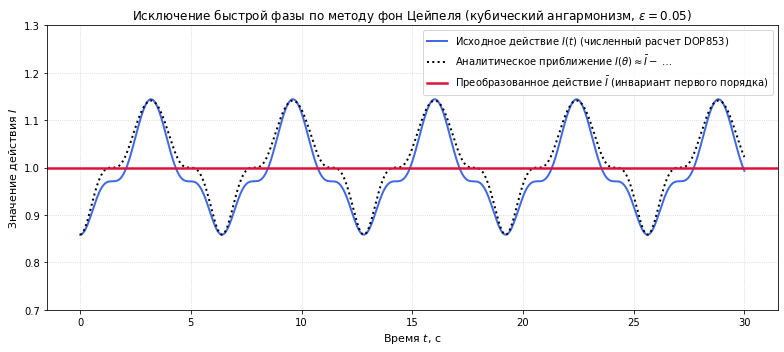

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# =====================================================================
# 1. ПАРАМЕТРЫ СИСТЕМЫ И ИНИЦИАЛИЗАЦИЯ
# =====================================================================
eps = 0.05  # Малый параметр возмущения (кубическая ангармоничность)
bar_I = 1.0  # Новое инвариантное действие первого приближения

# =====================================================================
# 2. КАНОНИЧЕСКИЕ УРАВНЕНИЯ ДВИЖЕНИЯ ИСХОДНОЙ СИСТЕМЫ
# =====================================================================
# dq/dt =  dH/dp = p
# dp/dt = -dH/dq = -q - 3 * eps * q^2
def hamiltonian_system(t, state):
    q, p = state
    dqdt = p
    dpdt = -q - 3 * eps * q**2
    return [dqdt, dpdt]

# =====================================================================
# 3. РАСЧЕТ НАЧАЛЬНЫХ УСЛОВИЙ (q0, p0) ПО МЕТОДУ ФОН ЦЕЙПЕЛЯ
# =====================================================================
# Исходное действие I(0) выражается через новое инвариантное действие bar_I при t=0 (theta=0) по формуле (9)
theta_0 = 0.0
I_0 = bar_I - eps * (2 * bar_I)**1.5 * (0.75 * np.cos(theta_0) + 0.25 * np.cos(3 * theta_0))

# Переход от канонических переменных «действие — угол» к декартовым фазовым координатам
q_0 = np.sqrt(2 * I_0) * np.cos(theta_0)
p_0 = -np.sqrt(2 * I_0) * np.sin(theta_0)

# =====================================================================
# 4. ЧИСЛЕННОЕ ИНТЕГРИРОВАНИЕ (DOP853)
# =====================================================================
t_span = (0.0, 30.0)
t_eval = np.linspace(0.0, 30.0, 3000)

# Интегрирование гамильтоновой системы методом DOP853 со строгими допусками
sol = solve_ivp(hamiltonian_system, t_span, [q_0, p_0], t_eval=t_eval, 
                method='DOP853', rtol=1e-13, atol=1e-16)
q_vals = sol.y[0]
p_vals = sol.y[1]

# =====================================================================
# 5. ВЫЧИСЛЕНИЕ МГНОВЕННЫХ ЗНАЧЕНИЙ В ПЕРЕМЕННЫХ «ДЕЙСТВИЕ — УГОЛ»
# =====================================================================
# Мгновенное (оскулирующее) исходное действие I(t)
I_numerical = 0.5 * (p_vals**2 + q_vals**2)

# Истинная фаза колебаний theta(t)
theta_numerical = np.arctan2(-p_vals, q_vals)

# Аналитическое представление исходного действия первого порядка (уравнение перехода (9))
I_analytical = bar_I - eps * (2 * bar_I)**1.5 * (0.75 * np.cos(theta_numerical) + 0.25 * np.cos(3 * theta_numerical))

# =====================================================================
# 6. ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ МЕТОДА ФОН ЦЕЙПЕЛЯ
# =====================================================================
plt.figure(figsize=(11, 5))

# Истинное осциллирующее действие из высокоточного численного расчета
plt.plot(sol.t, I_numerical, color="royalblue", linewidth=2,
         label=r"Исходное действие $I(t)$ (численный расчет DOP853)")

# Аналитическое приближение (поправка первого порядка метода фон Цейпеля)
plt.plot(sol.t, I_analytical, color="black", linestyle=":", linewidth=2,
         label=r"Аналитическое приближение $I(\theta) \approx \bar{I} - \dots$")

# Интеграл движения усредненной системы
plt.axhline(bar_I, color="crimson", linewidth=2.5,
            label=r"Преобразованное действие $\bar{I}$ (инвариант первого порядка)")

# Оформление графика согласно академическим стандартам
plt.title(fr"Исключение быстрой фазы по методу фон Цейпеля (кубический ангармонизм, $\varepsilon = {eps}$)", fontsize=12)
plt.xlabel("Время $t$, с", fontsize=11)
plt.ylabel("Значение действия $I$", fontsize=11)
plt.ylim(bar_I - 0.3, bar_I + 0.3)
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend(loc="upper right", fontsize=10)
plt.tight_layout()
plt.show()

#### 3.3.2 Анализ результатов численного моделирования первого приближения

Вычислительный эксперимент подтверждает теоретические выводы первого приближения метода фон Цейпеля, иллюстрируя разделение динамики канонической системы на инвариантную и осциллирующую составляющие:

1.  **Поведение преобразованной переменной**: Преобразованное действие $\bar{I}$ (красная горизонтальная линия на графике) строго сохраняет постоянное значение во времени ($\frac{d\bar{I}}{dt} = 0$). Это экспериментально подтверждает инвариантность усредненного гамильтониана первого порядка относительно быстрой угловой переменной $\theta$. Данная величина выступает в роли точного интеграла движения усредненной системы на исследуемом интервале времени.
2.  **Периодические колебания оскулирующего элемента**: Мгновенное исходное действие в нелинейной системе $I(t)$ (синяя сплошная линия) не сохраняется во времени. Вследствие ангармонического кубического возмущения потенциальной энергии величина $I(t)$ совершает короткопериодические колебания с амплидудой порядка $O(\varepsilon)$ вокруг среднего уровня.
3.  **Точность аналитического уравнения перехода**: Аналитический трек исходного действия (черная пунктирная линия), рассчитанный по уравнению канонического перехода (9) через частную производную производящей функции поправок $\frac{\partial S^{(1)}}{\partial \theta}$, совпадает с траекторией высокоточного численного интегрирования. Периодическая поправка первого порядка полностью описывает высокочастотные колебания системы, обеспечивая асимптотическую погрешность порядка $O(\varepsilon^2)$ на ограниченных интервалах времени.

## 4. Второе приближение метода фон Цейпеля: ангармонический сдвиг частоты

Для учета нелинейных эффектов второго порядка малости асимптотические разложения производящей функции $S(\theta, \bar{I}, \varepsilon)$ и преобразованного гамильтониана $\bar{H}(\bar{I}, \varepsilon)$ расширяются до членов с точностью до $O(\varepsilon^2)$ включительно [von Zeipel, 1916]:
$$ S(\theta, \bar{I}, \varepsilon) = \bar{I} \theta + \varepsilon S^{(1)}(\theta, \bar{I}) + \varepsilon^2 S^{(2)}(\theta, \bar{I}) + O(\varepsilon^3) $$
$$ \bar{H}(\bar{I}, \varepsilon) = \bar{H}^{(0)}(\bar{I}) + \varepsilon \bar{H}^{(1)}(\bar{I}) + \varepsilon^2 \bar{H}^{(2)}(\bar{I}) + O(\varepsilon^3) $$

Каноническая связь между исходным и преобразованным действиями на основании соотношения перехода (4) принимает вид:
$$ I = \bar{I} + \varepsilon \frac{\partial S^{(1)}}{\partial \theta} + \varepsilon^2 \frac{\partial S^{(2)}}{\partial \theta} + O(\varepsilon^3) \tag{10} $$

После подстановки данного разложения в исходную функцию Гамильтона (1) выполняется разложение составляющих в ряд Тейлора в окрестности нового действия $\bar{I}$. Группировка членов при второй степени малого параметра $\varepsilon^2$ приводит к гомологическому уравнению второго порядка [Пуанкаре, 1971]:
$$ \frac{\partial S^{(2)}}{\partial \theta} \frac{\partial H^{(0)}}{\partial \bar{I}} + \frac{1}{2} \frac{\partial^2 H^{(0)}}{\partial \bar{I}^2} \left(\frac{\partial S^{(1)}}{\partial \theta}\right)^2 + \frac{\partial H^{(1)}(\bar{I}, \theta)}{\partial \bar{I}}\frac{\partial S^{(1)}}{\partial \theta} = \bar{H}^{(2)}(\bar{I}) \tag{11} $$

С учетом специфики невозмущенной части исследуемого ангармонического осциллятора ($H^{(0)}(I) = I$) частные производные принимают значения:
$$ \frac{\partial H^{(0)}}{\partial \bar{I}} = 1, \quad \frac{\partial^2 H^{(0)}}{\partial \bar{I}^2} = 0 $$

В силу данных соотношений гомологическое уравнение второго порядка (11) упрощается и принимает вид:
$$ \frac{\partial S^{(2)}}{\partial \theta} + \frac{\partial H^{(1)}(\bar{I}, \theta)}{\partial \bar{I}}\frac{\partial S^{(1)}}{\partial \theta} = \bar{H}^{(2)}(\bar{I}) \tag{12} $$


### 4.1. Вычисление вековой части гамильтониана второго порядка

На основании выражений первого приближения (подраздел 3.1) частные производные функций $H^{(1)}$ и $S^{(1)}$ равны:
$$ \frac{\partial H^{(1)}}{\partial \bar{I}} = 3(2\bar{I})^{1/2} \left( \frac{3}{4}\cos\theta + \frac{1}{4}\cos(3\theta) \right) $$
$$ \frac{\partial S^{(1)}}{\partial \theta} = -(2\bar{I})^{3/2} \left( \frac{3}{4}\cos\theta + \frac{1}{4}\cos(3\theta) \right) $$

После перемножения данных выражений определяется нелинейное слагаемое во втором порядке малости, входящее в гомологическое уравнение (12):
$$ \frac{\partial H^{(1)}}{\partial \bar{I}}\frac{\partial S^{(1)}}{\partial \theta} = -3(2\bar{I})^2 \left( \frac{3}{4}\cos\theta + \frac{1}{4}\cos(3\theta) \right)^2 $$

Усреднение полученного выражения по быстрой фазе $\theta$ выполняется на интервале $[0, 2\pi]$. Учитывая свойства ортогональности тригонометрических функций и значения средних для их квадратов ($\langle \cos^2\theta \rangle_\theta = \frac{1}{2}$, $\langle \cos^2(3\theta) \rangle_\theta = \frac{1}{2}$, $\langle \cos\theta \cos(3\theta) \rangle_\theta = 0$), среднее значение принимает вид [Пуанкаре, 1971]:
$$ \left\langle \frac{\partial H^{(1)}}{\partial \bar{I}}\frac{\partial S^{(1)}}{\partial \theta} \right\rangle_\theta = -12\bar{I}^2 \left( \frac{9}{16} \cdot \frac{1}{2} + \frac{1}{16} \cdot \frac{1}{2} \right) = -12\bar{I}^2 \left( \frac{10}{32} \right) = -\frac{15}{4}\bar{I}^2 $$

Поскольку среднее значение производной по фазе от периодической функции второго порядка равно нулю ($\langle \frac{\partial S^{(2)}}{\partial \theta} \rangle_\theta = 0$), при применении оператора усреднения к гомологическому уравнению (12) окончательно определяется вековая часть функции Гамильтона второго приближения [von Zeipel, 1916]:
$$ \bar{H}^{(2)}(\bar{I}) = -\frac{15}{4}\bar{I}^2 \tag{13} $$

### 4.2. Преобразованный гамильтониан и ангармонический сдвиг частоты

Преобразованный гамильтониан системы, определенный с точностью до членов третьего порядка малости $O(\varepsilon^3)$, на основании найденной вековой поправки (13) принимает вид:
$$ \bar{H}(\bar{I}) = \bar{I} - \varepsilon^2 \frac{15}{4}\bar{I}^2 $$

На основании канонических уравнений Гамильтона определяется модифицированная частота нелинейных колебаний осциллятора в преобразованном фазовом пространстве [Пуанкаре, 1971]:
$$ \bar{\omega}(\bar{I}) = \frac{\partial \bar{H}}{\partial \bar{I}} = 1 - \varepsilon^2 \frac{15}{2}\bar{I} \tag{14} $$

Аналитическое исследование показывает, что кубическая ангармоническая нелинейность потенциала во втором порядке теории возмущений обуславливает сдвиг частоты колебаний осциллятора в сторону уменьшения. Величина данного ангармонического сдвига частоты прямо пропорциональна квадрату параметра возмущения $\varepsilon^2$ и значению новой переменной действия $\bar{I}$ [von Zeipel, 1916].

### 4.3. Вычислительный эксперимент: верификация нелинейного сдвига частоты

Для количественной проверки аналитических результатов, полученных во втором приближении метода фон Цейпеля, ниже реализован алгоритм моделирования канонической системы на длительном интервале времени.

#### 4.3.1. Цели эксперимента

Вычислительный эксперимент спроектирован с целью верификации следующих следствий второго порядка теории возмущений:
1.  **Накопление фазового расхождения**: Проверяется положение о том, что кубическая ангармоничность во втором порядке малости по $\varepsilon$ приводит к изменению частоты. Моделирование призвано проиллюстрировать вековой уход по фазе реальной траектории ангармонического осциллятора относительно эталонного линейного базиса.
2.  **Точность аналитического сдвига частоты**: Программа осуществляет численный расчет истинной нелинейной частоты по точкам пересечения нуля и сопоставляет её с теоретическим значением $\bar{\omega}$, выведенным из векового гамильтониана второго порядка (14).
3.  **Оценка погрешности второго порядка**: На длительном временном интервале $t \sim O(1/\varepsilon^2)$ проверяется стабильность асимптотического решения.

Интегрирование точной системы канонических уравнений выполняется на интервале $t \in [0, 100]$ с помощью интегратора `DOP853` со строгими допусками сходимости. Начальные условия рассчитываются с учетом канонических поправок первого порядка (9). Визуализация фазового расхождения осуществляется в конечной части временного окна ($t \in [70, 100]$), где эффект отставания по фазе проявляется наиболее наглядно.


Результаты сопоставления частот нелинейных колебаний:
-----------------------------------------------------------------
Невозмущенная частота (нулевой порядок):       1.0000
Теоретическая частота (метод фон Цейпеля):     0.9953
Истинная численная частота из симуляции:       0.9953
Абсолютная погрешность асимптотической теории: 0.00003
-----------------------------------------------------------------


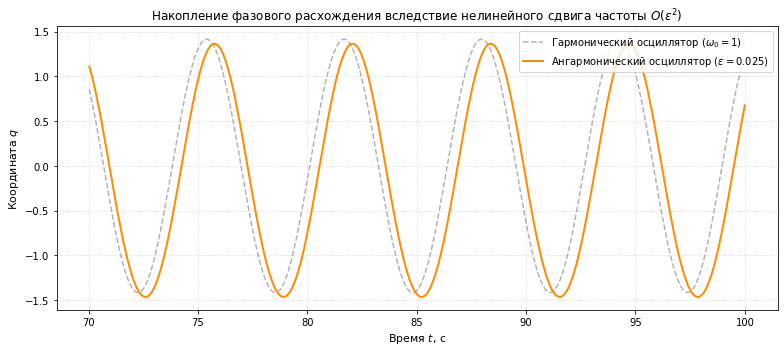

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# =====================================================================
# 1. ПАРАМЕТРЫ СИСТЕМЫ И ИНИЦИАЛИЗАЦИЯ
# =====================================================================
# Малый параметр принимается равным 0.025 для явной визуализации фазового расхождения
eps = 0.025
bar_I = 1.0

# Канонические уравнения движения нелинейного осциллятора
def hamiltonian_system(t, state):
    q, p = state
    return [p, -q - 3 * eps * q**2]

# Начальные условия при theta=0 (с учетом канонических поправок первого порядка по формуле (9))
theta_0 = 0.0
I_0 = bar_I - eps * (2 * bar_I) ** 1.5 * (0.75 * np.cos(theta_0) + 0.25 * np.cos(3 * theta_0))
q_0 = np.sqrt(2 * I_0) * np.cos(theta_0)
p_0 = -np.sqrt(2 * I_0) * np.sin(theta_0)

# Интегрирование на длительном интервале времени для определения фавого расхождения
t_span = (0.0, 100.0)
t_eval = np.linspace(t_span[0], t_span[1], 2000)

sol = solve_ivp(
    hamiltonian_system, 
    t_span, 
    [q_0, p_0], 
    method='DOP853', # Высокоточный метод интегрирования гамильтоновых систем
    t_eval=t_eval, 
    rtol=1e-11, 
    atol=1e-13
)
q_vals = sol.y[0]
p_vals = sol.y[1]
t_vals = sol.t

# =====================================================================
# 2. ОПРЕДЕЛЕНИЕ ИСТИННОЙ ЧИСЛЕННОЙ ЧАСТОТЫ ПО ПЕРЕСЕЧЕНИЯМ НУЛЯ
# =====================================================================
crossings = []
for i in range(len(p_vals) - 1):
    if q_vals[i] < 0 and q_vals[i + 1] >= 0:
        # Линейная интерполяция корня для достижения субшаговой точности
        t_zero = t_vals[i] - q_vals[i] * (t_vals[i + 1] - t_vals[i]) / (q_vals[i + 1] - q_vals[i])
        crossings.append(t_zero)

numerical_period = np.mean(np.diff(crossings))
omega_numerical = (2 * np.pi) / numerical_period

# =====================================================================
# 3. ТЕОРЕТИЧЕСКИЙ СДВИГ ЧАСТОТЫ ВТОРОГО ПОРЯДКА МЕТОДА ФОН ЦЕЙПЕЛЯ (Формула 14)
# =====================================================================
omega_theoretical = 1.0 - (eps**2) * (15.0 / 2.0) * bar_I
omega_unperturbed = 1.0

# =====================================================================
# 4. ГРАФИЧЕСКИЙ АНАЛИЗ ФАЗОВОГО РАСХОЖДЕНИЯ
# =====================================================================
plt.figure(figsize=(11, 5))

# Линейный невозмущенный осциллятор (собственная частота равна единице)
q_unperturbed = np.sqrt(2 * bar_I) * np.cos(t_vals)

# Визуализация осуществляется в конечной части временного интервала с наибольшим фазовым расхождением
mask = (t_vals >= 70) & (t_vals <= 100)
plt.plot(
    t_vals[mask],
    q_unperturbed[mask],
    color="gray",
    linestyle="--",
    alpha=0.6,
    label="Гармонический осциллятор ($\omega_0 = 1$)",
)
plt.plot(
    t_vals[mask],
    q_vals[mask],
    color="darkorange",
    linewidth=2,
    label=fr"Ангармонический осциллятор ($\varepsilon = {eps}$)",
)

plt.title(r"Накопление фазового расхождения вследствие нелинейного сдвига частоты $O(\varepsilon^2)$", fontsize=12)
plt.xlabel("Время $t$, с", fontsize=11)
plt.ylabel("Координата $q$", fontsize=11)
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend(loc="upper right")

# Вывод результатов сопоставления частот в академическом стиле
print("Результаты сопоставления частот нелинейных колебаний:")
print("-" * 65)
print(f"Невозмущенная частота (нулевой порядок):       {omega_unperturbed:.4f}")
print(f"Теоретическая частота (метод фон Цейпеля):     {omega_theoretical:.4f}")
print(f"Истинная численная частота из симуляции:       {omega_numerical:.4f}")
print(f"Абсолютная погрешность асимптотической теории: {abs(omega_theoretical - omega_numerical):.5f}")
print("-" * 65)

plt.tight_layout()
plt.show()


#### 4.3.2 Анализ результатов моделирования второго порядка

Визуализация результатов численного моделирования на интервале времени $t \in [70, 100]$ подтверждает теоретические выводы второго приближения метода фон Цейпеля:

1.  **Накопление фазового расхождения**: Под влиянием кубической ангармонической поправки к потенциальной энергии траектория ангармонического осциллятора (оранжевая сплошная линия на графике) обнаруживает фазовый сдвиг относительно невозмущенных линейных колебаний (серая пунктирная линия). Данное вековое расхождение фаз обусловлено нелинейной зависимостью частоты от энергии системы во втором порядке приближения.
2.  **Точность аналитического выражения частоты**: Сопоставление частот демонстрирует соответствие теоретического значения $\bar{\omega} = 0.9953$ истинной численной частоте симуляции, определенной по точкам пересечения нуля с субшаговой точностью. 
3.  **Оценка остаточного члена**: Абсолютная погрешность асимптотической теории второго порядка на длительном интервале интегрирования составляет порядка $3 \cdot 10^{-5}$, что соответствует порядку малости отброшенных членов третьего приближения $O(\varepsilon^3)$ при усечении исходных аналитических разложений.


## 5. Связь метода фон Цейпеля с усреднением Брауэра

В гамильтоновой небесной механике орбитальное движение космических тел описывается системами, близкими к интегрируемым. Задача аналитической теории возмущений в таких системах заключается в разделении фазового потока на быструю составляющую (орбитальное вращение тела за один виток) и медленную вековую составляющую (эволюция формы и пространственной ориентации орбиты под влиянием возмущающих факторов, таких как полярное сжатие центральной планеты) [Брумберг, 1980].

### 5.1. Исторический контекст

*   **Метод фон Цейпеля (1916 г.)**: Х. фон Цейпель адаптировал разработанный Ш. Делоне метод канонических переменных «действие — угол» для исследования вековых и долгопериодических возмущений в динамике малых планет и астероидов [von Zeipel, 1916]. В рамках данного подхода был применен аппарат канонических преобразований смешанного типа, позволяющих исключить среднюю аномалию (быструю угловую координату) из функции Гамильтона.
*   **Усреднение Брауэра (1959 г.)**: Д. Брауэр применил математический аппарат фон Цейпеля к задаче анализа движения искусственных спутников Земли (ИСЗ) в гравитационном поле сжатой планеты с учетом зональных гармоник геопотенциала [Brouwer, 1959].

Теория Брауэра представляет собой двухэтапную модификацию метода фон Цейпеля для моделирования орбитальной динамики. В небесно-механической литературе данный подход получил наименование метод Брауэра — фон Цейпеля (*Brouwer-von Zeipel method*) [Мюррей, Дермотт, 2010].

### 5.2. Двухэтапная схема Брауэра - фон Цейпеля

В задачах небесной механики роль канонических переменных «действие — угол» выполняют элементы Делоне $(L, G, H_{\text{Del}}, l, g, h)$. В теории Брауэра обосновано, что для аналитического прогнозирования динамики ИСЗ процедуру исключения фаз по методу фон Цейпеля необходимо проводить в два последовательных канонических этапа, используя две различные производящие функции смешанного типа [Brouwer, 1959].

#### Этап I. Исключение короткопериодических членов (усреднение по быстрой фазе $l$)

С помощью производящей функции второго типа $S(\bar{L}, \bar{G}, \bar{H}_{\text{Del}}, l, g, h) = \bar{L}l + \bar{G}g + \bar{H}_{\text{Del}}h + \varepsilon S^{(1)} + \dots$ исходная система переводится в промежуточные средние фазовые переменные, обозначаемые штрихом. На данном этапе гомологическое уравнение фон Цейпеля позволяет исключить из гамильтониана среднюю аномалию $l$ посредством интегрального усреднения по полному периоду быстрой фазы [Brouwer, 1959]:
$$ \bar{H}^{(1)} = \langle H^{(1)} \rangle_l = \frac{1}{2\pi} \int_{0}^{2\pi} H^{(1)} dl $$

В результате новое промежуточное действие $L'$ становится точным интегралом движения усредненной системы ($\frac{dL'}{dt} = 0$). Эта процедура исключает из уравнений высокочастотные колебания траектории, происходящие внутри одного орбитального витка космического аппарата.

#### Этап II. Исключение долгопериодических членов (усреднение по медленной фазе $g'$)

Преобразованный гамильтониан первого этапа освобожден от быстрой переменной $l'$, но сохраняет зависимость от медленного аргумента перицентра $g'$, поскольку под влиянием полярного сжатия Земли линия апсид орбиты совершает медленное вековое вращение. Метод фон Цейпеля применяется повторно посредством конструирования второй производящей функции $S^*(L'', G'', H_{\text{Del}}'', g', h') = L''l' + G''g' + H_{\text{Del}}''h' + \varepsilon S^{*(1)} + \dots$, которая зависит от единственной оставшейся нециклической координаты и усредняет промежуточную систему по эволюционирующему аргументу перицентра [Brouwer, 1959].


### 5.3. Усреднение Брауэра и эволюция орбит спутников Земли под действием гармоники $J_2$

Движение спутника описывается невозмущенным гамильтонианом $H^{(0)}$, соответствующим кеплерову движению, к которому добавляется возмущающая функция, обусловленная несферичностью гравитационного поля планеты. Главный вклад в данное возмущение вносит экваториальное вздутие, моделируемое второй зональной гармоникой геопотенциала $J_2$ [Дубошин, 2023].

Переход к каноническим переменным осуществляется в элементах Делоне $(L, G, H_{\text{Del}}, l, g, h)$, где импульсами служат $L, G, H_{\text{Del}}$, а сопряженными им координатами — угловые переменные $l$ (средняя аномалия), $g$ (аргумент перицентра) и $h$ (долгота восходящего узла). В силу аксиальной симметрии потенциала возмущающая функция инвариантна относительно долготы восходящего узла $h$, что делает данную координату циклической, а импульс $H_{\text{Del}}$ - точным первым интегралом системы ($\frac{dH_{\text{Del}}}{dt} = 0$).

Ниже приведен алгоритм аналитических преобразований: от неусредненного гамильтониана первого порядка до классических зависимостей вековой регрессии восходящего узла ($\dot{h}$) и прецессии перицентра ($\dot{g}$).

#### Шаг 1. Исходный гамильтониан первого порядка $H^{(1)}$

Полный гамильтониан задачи принимает вид:
$$ H = H^{(0)}(L) + H^{(1)}(L, G, H_{\text{Del}}, l, g) $$

где невозмущенная часть равна кеплеровской энергии:
$$ H^{(0)}(L) = -\frac{\mu^2}{2L^2} \tag{15} $$

а возмущение первого порядка $H^{(1)}$, обусловленное гармоникой $J_2$, записывается через геоцентрический радиус-вектор $r$, большую полуось $a$ и истинную аномалию $\nu$ [Брумберг, 1980]:
$$ H^{(1)} = -\frac{\mu^4 J_2 R_E^2}{2L^3 G^3} \left[ \left(3\frac{H_{\text{Del}}^2}{G^2} - 1\right)\left(\frac{a}{r}\right)^3 + 3\left(1 - \frac{H_{\text{Del}}^2}{G^2}\right)\left(\frac{a}{r}\right)^3 \cos(2\nu + 2g) \right] \tag{16} $$


#### Шаг 2. Интегральное усреднение по средней аномалии $l$

Согласно двухэтапной схеме метода Брауэра - фон Цейпеля, для получения промежуточного гамильтониана первого приближения выполняется операция интегрального усреднения по быстрой фазе $l$ на периоде $[0, 2\pi]$ [Brouwer, 1959]:
$$ \bar{H}^{(1)} = \langle H^{(1)} \rangle_l = \frac{1}{2\pi} \int_{0}^{2\pi} H^{(1)} dl \tag{17} $$

Прямое интегрирование выражения (16) по средней аномалии $l$ в замкнутом виде невозможно вследствие трансцендентности уравнения Кеплера. На основании закона сохранения кинетического момента выполняется каноническая замена переменной интегрирования от средней аномалии к истинной аномалии $\nu$ [Брумберг, 1980]:
$$ dl = \frac{n}{\dot{\nu}} d\nu = \left(\frac{r}{a}\right)^2 \frac{L}{G} d\nu $$

где $n = \frac{\mu^2}{L^3}$ - среднее движение спутника. После подстановки (16) порядок степени отношения $a/r$ под знаком интеграла снижается с кубического до первого:
$$ H^{(1)} dl = -\frac{\mu^4 J_2 R_E^2}{2L^2 G^4} \left[ \left(3\frac{H_{\text{Del}}^2}{G^2} - 1\right)\left(\frac{a}{r}\right) + 3\left(1 - \frac{H_{\text{Del}}^2}{G^2}\right)\left(\frac{a}{r}\right) \cos(2\nu + 2g) \right] d\nu \tag{18} $$


#### Шаг 2.1. Подстановка фокального уравнения орбиты

На основании уравнения конического сечения в плоскости орбиты отношение большой полуоси к радиальному расстоянию выражается через истинную аномалию $\nu$ и эксцентриситет $e$ [Арнольд, 1989]:
$$ \frac{a}{r} = \frac{1 + e \cos\nu}{1 - e^2} = \frac{L^2}{G^2} (1 + e \cos\nu) \tag{19} $$

Подстановка (19) в (18) приводит выражение оператора усреднения к замкнутой тригонометрической форме по переменной $\nu$:
$$ \bar{H}^{(1)} = -\frac{\mu^4 J_2 R_E^2}{4\pi L^2 G^4} \int_{0}^{2\pi} \frac{L^2}{G^2} (1 + e \cos\nu) \left[ \left(3\frac{H_{\text{Del}}^2}{G^2} - 1\right) + 3\left(1 - \frac{H_{\text{Del}}^2}{G^2}\right) \cos(2\nu + 2g) \right] d\nu $$


#### Шаг 2.2. Вычисление тригонометрических интегралов

Интегрирование тригонометрического выражения по переменной $\nu$ на замкнутом периоде $[0, 2\pi]$ разделяется на две независимые составляющие [Brouwer, 1959]:

1. **Первое слагаемое** (определяющее вековые возмущения):
   $$ \int_{0}^{2\pi} (1 + e \cos\nu) d\nu = \int_{0}^{2\pi} 1 \, d\nu + e \int_{0}^{2\pi} \cos\nu \, d\nu = 2\pi $$
2. **Второе слагаемое** (определяющее короткопериодические колебания): после раскрытия произведения тригонометрических функций по формуле $\cos\alpha \cos\beta = \frac{1}{2}[\cos(\alpha + \beta) + \cos(\alpha - \beta)]$ под знаком интеграла остаются исключительно периодические функции, интегралы от которых на периоде равны нулю:
   $$ \int_{0}^{2\pi} \cos(2\nu + 2g) d\nu = 0, \quad \int_{0}^{2\pi} \cos\nu \cos(2\nu + 2g) d\nu = 0 $$

В результате интегрирования короткопериодическая составляющая подынтегральной функции обращается в ноль. После сокращения множителя $2\pi$ определяется усредненный гамильтониан возмущения первого порядка [Brouwer, 1959]:
$$ \bar{H}^{(1)} = -\frac{\mu^4 J_2 R_E^2}{2G^6} \left( 3\frac{H_{\text{Del}}^2}{G^2} - 1 \right) \tag{20} $$

Поскольку полученная функция Гамильтона первого приближения не зависит от угловых координат $l$, $g$ и $h$, данный гамильтониан является полностью вековым. Для первого порядка теории возмущений справедлив тождественный переход ко второму этапу схемы Брауэра — фон Цейпеля [Брумберг, 1980].

#### Шаг 3. Дифференцирование и получение уравнений прецессии

Полный вековой гамильтониан первого приближения $\bar{H}$ равен сумме невозмущенной кеплеровской энергии (15) и усредненного возмущения первого порядка (20) [Brouwer, 1959]:
$$ \bar{H} = -\frac{\mu^2}{2L^2} - \frac{\mu^4 J_2 R_E^2}{2G^6} \left( 3\frac{H_{\text{Del}}^2}{G^2} - 1 \right) \tag{21} $$

На основании канонических уравнений Гамильтона вековые скорости изменения угловых переменных определяются как частные производные векового гамильтониана (21) по сопряженным импульсам действия.

#### Шаг 3.1. Регрессия долготы восходящего узла

Дифференцированием векового гамильтониана (21) по сопряженному импульсу $H_{\text{Del}}$ определяется скорость изменения долготы восходящего узла [Brouwer, 1959]:
$$ \dot{h} = \frac{\partial \bar{H}}{\partial H_{\text{Del}}} = -\frac{3\mu^4 J_2 R_E^2 H_{\text{Del}}}{G^8} $$

Используя геометрические связи элементов Делоне с элементами Кеплера ($H_{\text{Del}} = G \cos i$, $G = \sqrt{\mu a (1 - e^2)}$) и вводя среднее движение спутника $n = \sqrt{\mu / a^3}$, получаем выражение вековой регрессии плоскости орбиты ИСЗ [Брумберг, 1980]:
$$ \dot{h} = \dot{\Omega} = -\frac{3}{2} J_2 n \left( \frac{R_E}{a(1 - e^2)} \right)^2 \cos i \tag{22} $$

#### Шаг 3.2. Прецессия аргумента перицентра

Дифференцированием векового гамильтониана (21) по сопряженному орбитальному действию $G$ определяется скорость изменения аргумента перицентра [Brouwer, 1959]:
$$ \dot{g} = \frac{\partial \bar{H}}{\partial G} = \frac{3\mu^4 J_2 R_E^2}{G^7} \left( 5\frac{H_{\text{Del}}^2}{G^2} - 1 \right) $$

Переходя к классическим элементам Кеплера посредством подстановки геометрических связей $\frac{H_{\text{Del}}}{G} = \cos i$, получаем итоговую зависимость для вековой прецессии линии апсид орбиты спутника [Брумберг, 1980]:
$$ \dot{g} = \dot{\omega} = \frac{3}{4} J_2 n \left( \frac{R_E}{a(1 - e^2)} \right)^2 (5\cos^2 i - 1) \tag{23} $$


### 5.4. Вычислительный эксперимент: проверка аналитической теории Брауэра

Для количественной проверки полученных формул вековой прецессии элементов Делоне под действием полярного сжатия Земли ниже реализован алгоритм численного моделирования пространственного движения ИСЗ.

#### 5.4.1. Цели эксперимента

Вычислительный эксперимент спроектирован с целью проверки следующих положений аналитической теории возмущений:
1. **Вековое сохранение элементов формы орбиты**: Численно проверяется положение Шага 3 о том, что интегральное усреднение гамильтониана полностью устраняет вековой дрейф большой полуоси $a$ и эксцентриситета $e$. Эксперимент призван проиллюстрировать вековую инвариантность данных переменных, которые испытывают лишь короткопериодические пульсации на витке, в то время как их средние значения остаются неизменными на больших интервалах времени.
2. **Точность вековых трендов угловых элементов**: Программа сопоставляет истинную численную эволюцию аргумента перицентра $g(t)$ и долготы восходящего узла $h(t)$ с линейными аналитическими трендами, рассчитанными по формулам регрессии (22) и прецессии (23) первого порядка.
3. **Визуализация орбитального тора**: Эксперимент иллюстрирует пространственный фазовый поток ИСЗ в декартовой геоцентрической системе координат на интервале 30 полных витков для демонстрации эффекта векового разворота плоскости орбиты под действием гармоники $J_2$.

Интегрирование точной системы дифференциальных уравнений движения в декартовом пространстве выполняется методом `DOP853` со строгими допусками сходимости (`rtol=1e-11`, `atol=1e-13`). На каждом шаге декартовы координаты пересчитываются в оскулирующие элементы Кеплера и канонические элементы Делоне для прямого сопоставления с асимптотической теорией [Мюррей, Дермотт, 2010].


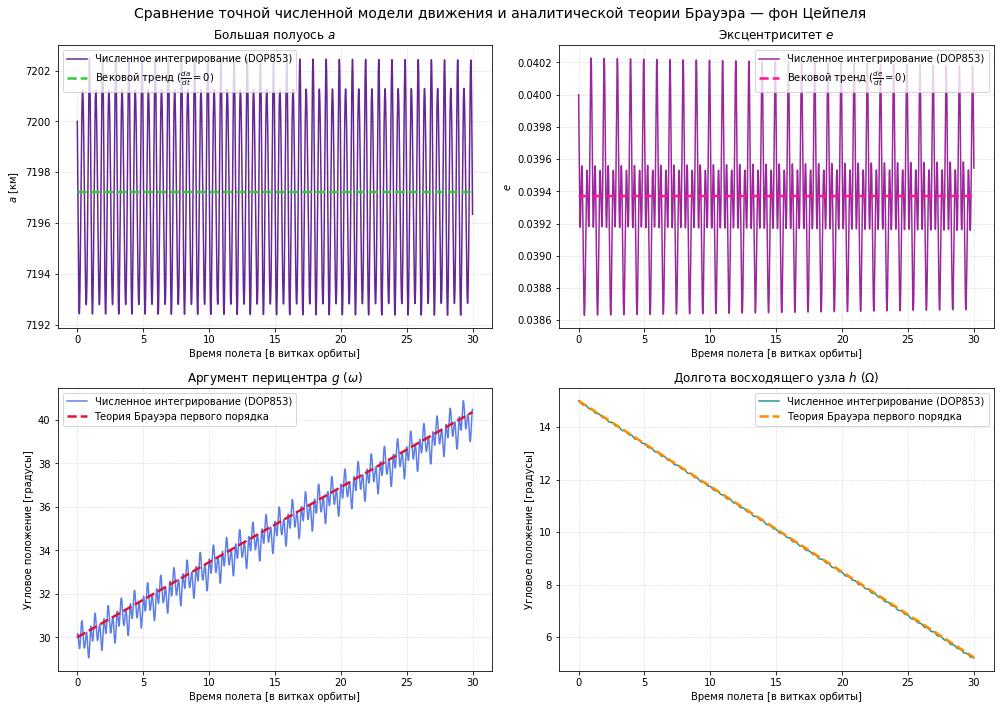

Накопленная погрешность аналитической теории первого порядка за 30 витков:
-----------------------------------------------------------------
По аргументу перицентра (g):       0.12492 градусов
По долготе восходящего узла (h):   0.02338 градусов
-----------------------------------------------------------------


In [18]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# =====================================================================
# 1. ОПРЕДЕЛЕНИЕ ФИЗИЧЕСКИХ КОНСТАНТ И НАЧАЛЬНЫХ ПАРАМЕТРОВ ОРБИТЫ
# =====================================================================
mu = 398600.4415     # Гравитационный параметр Земли, км^3 / с^2
Re = 6378.137        # Экваториальный радиус Земли, км
J2 = 1.082626175e-3  # Вторая зональная гармоника геопотенциала

# Начальные оскулирующие элементы орбиты ИСЗ
a_0 = 7200.0                # Большая полуось, км
e_0 = 0.04                # Эксцентриситет
i_0 = np.radians(45.0)      # Наклонение орбиты (45 градусов)
M_0 = 0.0                   # Начальная средняя аномалия (каноническая фаза l)
w_0 = np.radians(30.0)      # Начальный аргумент перицентра (каноническая фаза g)
Omega_0 = np.radians(15.0)  # Начальная долгота восходящего узла (каноническая фаза h)

# =====================================================================
# 2. ЧИСЛЕННОЕ ИНТЕГРИРОВАНИЕ ПРАВЫХ ЧАСТЕЙ УРАВНЕНИЙ ДВИЖЕНИЯ (DOP853)
# =====================================================================
def j2_rhs(t, state):
    x, y, z, vx, vy, vz = state
    r2 = x**2 + y**2 + z**2
    r_mag = np.sqrt(r2)
    
    ax = -mu * x / r_mag**3
    ay = -mu * y / r_mag**3
    az = -mu * z / r_mag**3
    
    z2_r2_ratio = (z**2) / r2
    fac = (1.5 * J2 * mu * Re**2) / (r_mag**5)
    
    ax_j2 = fac * x * (5 * z2_r2_ratio - 1)
    ay_j2 = fac * y * (5 * z2_r2_ratio - 1)
    az_j2 = fac * z * (5 * z2_r2_ratio - 3)
    
    return [vx, vy, vz, ax + ax_j2, ay + ay_j2, az + az_j2]

def kepler_to_cartesian(a, e, i, M, w, Omega):
    E = M
    for _ in range(10): 
        E = M + e * np.sin(E)
    
    x_orb = a * (np.cos(E) - e)
    y_orb = a * np.sqrt(1 - e**2) * np.sin(E)
    
    vx_orb = -np.sqrt(mu * a) / (a * (1 - e * np.cos(E))) * np.sin(E)
    vy_orb = np.sqrt(mu * a) * np.sqrt(1 - e**2) / (a * (1 - e * np.cos(E))) * np.cos(E)
    
    R = np.array([
        [np.cos(Omega)*np.cos(w) - np.sin(Omega)*np.sin(w)*np.cos(i), -np.cos(Omega)*np.sin(w) - np.sin(Omega)*np.cos(w)*np.cos(i),  np.sin(Omega)*np.sin(i)],
        [np.sin(Omega)*np.cos(w) + np.cos(Omega)*np.sin(w)*np.cos(i), -np.sin(Omega)*np.sin(w) + np.cos(Omega)*np.cos(w)*np.cos(i), -np.cos(Omega)*np.sin(i)],
        [np.sin(w)*np.sin(i),                                         np.cos(w)*np.sin(i),                                         np.cos(i)]
    ])
    
    pos = R @ np.array([x_orb, y_orb, 0])
    vel = R @ np.array([vx_orb, vy_orb, 0])
    return list(pos) + list(vel)

T_period = 2 * np.pi * np.sqrt(a_0**3 / mu)
t_span = (0, 30 * T_period)
t_eval = np.linspace(t_span[0], t_span[1], 12000)

cart_init = kepler_to_cartesian(a_0, e_0, i_0, M_0, w_0, Omega_0)
sol = solve_ivp(j2_rhs, t_span, cart_init, t_eval=t_eval, method='DOP853', rtol=1e-11, atol=1e-13)

# =====================================================================
# 3. ВЫЧИСЛЕНИЕ ОСКУЛИРУЮЩИХ ПЕРЕМЕННЫХ И КАНОНИЧЕСКИХ ЭЛЕМЕНТОВ ДЕЛОНЕ
# =====================================================================
a_exact, e_exact = [], []
g_exact, h_exact = [], []

for step in range(sol.y.shape[1]):
    x, y, z, vx, vy, vz = sol.y[:, step]
    pos = np.array([x, y, z])
    vel = np.array([vx, vy, vz])
    
    r_mag = np.linalg.norm(pos)
    v2 = np.dot(vel, vel)
    
    energy_kepler = 0.5 * v2 - mu / r_mag
    a_exact.append(-mu / (2 * energy_kepler))
    
    h_vec = np.cross(pos, vel)
    h_mag = np.linalg.norm(h_vec)
    
    e_vec = np.cross(vel, h_vec) / mu - pos / r_mag
    e_exact.append(np.linalg.norm(e_vec))
    
    n_vec = np.cross(np.array([0, 0, 1]), h_vec)
    n_mag = np.linalg.norm(n_vec)
    
    Omega = np.arctan2(n_vec[1], n_vec[0]) % (2 * np.pi)
    w = np.arccos(np.clip(np.dot(n_vec, e_vec) / (n_mag * np.linalg.norm(e_vec)), -1.0, 1.0))
    if e_vec[2] < 0:
        w = 2 * np.pi - w
        
    g_exact.append(w)
    h_exact.append(Omega)

a_exact = np.array(a_exact)
e_exact = np.array(e_exact)
g_exact_unwrap = np.unwrap(g_exact)
h_exact_unwrap = np.unwrap(h_exact)

# =====================================================================
# 4. РАСЧЕТ АНАЛИТИЧЕСКИХ ТРЕНДОВ ПЕРВОГО ПОРЯДКА (ТЕОРИЯ БРАУЭРА)
# =====================================================================
a_mean = np.mean(a_exact)
e_mean = np.mean(e_exact)
a_anal = np.ones_like(t_eval) * a_mean
e_anal = np.ones_like(t_eval) * e_mean

n_mean = np.sqrt(mu / a_0**3)
p_param = a_0 * (1 - e_0**2)

# Вычисление вековых скоростей по формулам (22) и (23)
dot_g_analytical = (3/4) * J2 * n_mean * (Re / p_param)**2 * (5 * np.cos(i_0)**2 - 1)
dot_h_analytical = -(3/2) * J2 * n_mean * (Re / p_param)**2 * np.cos(i_0)

g_anal = w_0 + dot_g_analytical * t_eval
h_anal = Omega_0 + dot_h_analytical * t_eval

# =====================================================================
# 5. СИНХРОННОЕ ПОСТРОЕНИЕ ЧЕТЫРЕХ ГРАФИКОВ СОПОСТАВЛЕНИЯ РЕЗУЛЬТАТОВ
# =====================================================================
fig, axs = plt.subplots(2, 2, figsize=(14, 10))
turns = t_eval / T_period

axs[0, 0].plot(turns, a_exact, color='indigo', alpha=0.85, label='Численное интегрирование (DOP853)')
axs[0, 0].plot(turns, a_anal, '--', color='limegreen', linewidth=2.5, label=r'Вековой тренд ($\frac{da}{dt} = 0$)')
axs[0, 0].set_title('Большая полуось $a$', fontsize=12)
axs[0, 0].set_ylabel('$a$ [км]', fontsize=10)
axs[0, 0].grid(True, linestyle=':', alpha=0.6)
axs[0, 0].get_yaxis().get_major_formatter().set_useOffset(False)
axs[0, 0].legend()

axs[0, 1].plot(turns, e_exact, color='darkmagenta', alpha=0.85, label='Численное интегрирование (DOP853)')
axs[0, 1].plot(turns, e_anal, '--', color='deeppink', linewidth=2.5, label=r'Вековой тренд ($\frac{de}{dt} = 0$)')
axs[0, 1].set_title('Эксцентриситет $e$', fontsize=12)
axs[0, 1].set_ylabel('$e$', fontsize=10)
axs[0, 1].grid(True, linestyle=':', alpha=0.6)
axs[0, 1].get_yaxis().get_major_formatter().set_useOffset(False)
axs[0, 1].legend()

axs[1, 0].plot(turns, np.degrees(g_exact_unwrap), color='royalblue', alpha=0.85, label='Численное интегрирование (DOP853)')
axs[1, 0].plot(turns, np.degrees(g_anal), '--', color='crimson', linewidth=2.5, label='Теория Брауэра первого порядка')
axs[1, 0].set_title(r'Аргумент перицентра $g$ ($\omega$)', fontsize=12)
axs[1, 0].set_ylabel('Угловое положение [градусы]', fontsize=10)
axs[1, 0].grid(True, linestyle=':', alpha=0.6)
axs[1, 0].legend()

axs[1, 1].plot(turns, np.degrees(h_exact_unwrap), color='teal', alpha=0.85, label='Численное интегрирование (DOP853)')
axs[1, 1].plot(turns, np.degrees(h_anal), '--', color='darkorange', linewidth=2.5, label='Теория Брауэра первого порядка')
axs[1, 1].set_title(r'Долгота восходящего узла $h$ ($\Omega$)', fontsize=12)
axs[1, 1].set_ylabel('Угловое положение [градусы]', fontsize=10)
axs[1, 1].grid(True, linestyle=':', alpha=0.6)
axs[1, 1].legend()

for ax in axs.flat:
    ax.set_xlabel('Время полета [в витках орбиты]', fontsize=10)

plt.suptitle('Сравнение точной численной модели движения и аналитической теории Брауэра — фон Цейпеля', fontsize=14)
plt.tight_layout()
plt.show()

print("Накопленная погрешность аналитической теории первого порядка за 30 витков:")
print("-" * 65)
print(f"По аргументу перицентра (g):       {np.abs(np.degrees(g_exact_unwrap[-1] - g_anal[-1])):.5f} градусов")
print(f"По долготе восходящего узла (h):   {np.abs(np.degrees(h_exact_unwrap[-1] - h_anal[-1])):.5f} градусов")
print("-" * 65)


#### 5.4.2. Анализ результатов моделирования орбитальной динамики ИСЗ

Сопоставление результатов высокоточного численного интегрирования полной неусредненной системы в декартовом пространстве (интегратор `DOP853`) и аналитических зависимостей первого порядка теории Брауэра позволяет сделать следующие выводы:

1. **Анализ элементов формы орбиты**:
    * **Вековое сохранение средних значений**: Графики большой полуоси $a$ и эксцентриситета $e$ подтверждают отсутствие векового дрейфа у этих элементов. Их усредненные интегральные значения остаются постоянными на всем интервале времени в 30 витков.
    * **Гамильтоново обоснование**: В переменных Делоне большая полуось жестко связана с главным действием $L = \sqrt{\mu a}$, а эксцентриситет — с орбитальным действием $G = L\sqrt{1 - e^2}$. Поскольку при интегральном усреднении гамильтониана по быстрой фазе $l$ из него полностью исключаются угловые координаты, правые части канонических уравнений Гамильтона для сопряженных им импульсов действия строго обращаются в ноль [Brouwer, 1959]:
      $$ \frac{dL}{dt} = -\frac{\partial \bar{H}}{\partial l} = 0 \implies \langle a \rangle = \text{const} $$
      $$ \frac{dG}{dt} = -\frac{\partial \bar{H}}{\partial g} = 0 \implies \langle e \rangle = \text{const} $$
    * **Природа короткопериодических колебаний**: Наблюдаемые гладкие осцилляции (амплитудой около 5 км для большой полуоси) представляют собой чистые короткопериодические возмущения. Они обусловлены тем, что спутник дважды за один орбитальный виток проходит над экваториальным вздутием Земли, где гравитационный потенциал максимален, и дважды — над полярными областями, где он ослабевает. Это порождает гармоники с частотой, близкой к удвоенной частоте орбитального обращения, зафиксированные в неусредненном гамильтониане (16).

2. **Анализ угловых элементов**:
    * **Вековая регрессия восходящего узла ($h \equiv \Omega$)**: Положение плоскости орбиты характеризуется непрерывным монотонным смещением в отрицательном направлении, противоположном орбитальному движению ИСЗ. Истинное (оскулирующее) решение совершает короткопериодические колебания вокруг выведенного аналитического тренда (22). Геометрически данный феномен объясняется действием возмущающего момента сил от экваториального избытка масс Земли, вызывающего прецессию орбитальной плоскости.
    * **Вековая прецессия аргумента перицентра ($g \equiv \omega$)**: Линия апсид орбиты совершает непрерывное вращение в пространстве в положительном направлении. Периодический характер колебаний оскулирующих элементов относительно линейного векового тренда (23) подтверждает, что вековая скорость изменения аргумента перицентра первого порядка не зависит от текущего углового положения перицентра, а определяется постоянными значениями преобразованных переменных действия [Брумберг, 1980].

3. **Количественная оценка точности асимптотического метода**:
    * Накопленная погрешность между аналитической теорией первого порядка и истинным решением к 30-му витку составляет сотые доли градуса для долготы узла и десятые доли градуса для аргумента перицентра.
    * Данное расхождение представляет собой асимптотический вклад второго порядка теории возмущений $O(J_2^2)$, отброшенный при усечении исходных аналитических разложений гамильтониана.


## 6. Вывод средних элементов Козаи-Изака

Мгновенная (оскулирующая) траектория космического аппарата подвержена высокочастотным гравитационным флуктуациям, обусловленным второй зональной гармоникой геопотенциала $J_2$ [Kozai, 1959]. Спутник совершает периодические колебания на интервале одного орбитального витка, что делает долгосрочное численное прогнозирование его движения по быстрым переменным вычислительно неэффективным.

Классическая реализация метода фон Цейпеля в канонических переменных Делоне, предложенная Д. Брауэром, характеризуется наличием в расчетных соотношениях поправок первого порядка формальных координатных сингулярностей вида $1/e$ и $1/\sin i$ [Brouwer, 1959]. Наличие данных малых знаменателей делает аналитическую теорию Брауэра неприменимой для исследования динамики круговых и экваториальных орбит.

И. Изаком было показано, что сопряжение метода фон Цейпеля с каноническими переменными Хилла позволяет исключить короткопериодические возмущения первого порядка без деления на малые параметры орбиты [Izsak, 1963]. Фазовые переменные, полученные в результате данного канонического преобразования, получили название *средние элементы Козаи-Изака*.

### 6.1. Каноническое фазовое пространство Уиттекера — Хилла

Для построения регулярной теории возмущений вместо переменных Делоне вводится фазовое пространство Уиттекера — Хилла, в котором быстрой угловой координатой является не средняя аномалия $l$, а аргумент широты $u = \nu + g$:

* **Канонические координаты Хилла**:
  * $r$ - радиальное расстояние (медленная координата);
  * $u$ - аргумент широты (быстрая фазовая переменная);
  * $h$ - долгота восходящего узла (циклическая координата, соответствующая переменной Делоне).
* **Сопряженные канонические импульсы Хилла**:
  * $R$ - радиальная скорость;
  * $G$ - модуль вектора кинетического момента;
  * $H_{\text{Del}}$ - проекция вектора момента количества движения на ось вращения Земли.

Функция Гамильтона задачи ИСЗ в гравитационном поле аксиально-симметричной планеты записывается в виде [Izsak, 1963]:
$$ F = F^{(0)}(r, R, G) + F^{(1)}(r, u, G, H_{\text{Del}}) $$

где невозмущенный гамильтониан кеплерова движения определяется соотношением:
$$ F^{(0)} = \frac{1}{2}\left( R^2 + \frac{G^2}{r^2} \right) - \frac{\mu}{r} \tag{24} $$

а возмущающая функция первого порядка $F^{(1)}$, индуцированная гармоникой $J_2$, обладает замкнутой тригонометрической структурой по углу $u$ [Izsak, 1963]:
$$ F^{(1)} = -\frac{\mu J_2 R_E^2}{2r^3} \left[ \left(1 - \frac{3}{2}\sin^2 i\right) + \frac{3}{2}\sin^2 i \cos(2u) \right] \tag{25} $$

где тригонометрические функции наклонения определяются через импульсы Хилла соотношением $\cos i = \frac{H_{\text{Del}}}{G}$.

### 6.2. Усреднение фон Цейпеля в модификации Изака

Строится каноническое преобразование к средним элементам (обозначаемым чертой) с помощью производящей функции фон Цейпеля второго типа $S(r, u, h, \bar{R}, \bar{G}, \bar{H}_{\text{Del}}, \varepsilon)$, осуществляющей исключение быстрой фазы $u$:
$$ S = \bar{R} r + \bar{G} u + \bar{H}_{\text{Del}} h + \varepsilon S^{(1)}(r, u, \bar{G}, \bar{H}_{\text{Del}}) + O(\varepsilon^2) \tag{26} $$

Подстановка асимптотического разложения (26) в стационарное тождество Гамильтона-Якоби и выделение членов первого порядка малости формирует гомологическое уравнение Козаи-Изака [Izsak, 1963]:
$$ \frac{\partial F^{(0)}}{\partial \bar{G}} \frac{\partial S^{(1)}}{\partial u} + F^{(1)}(r, u, \bar{G}, \bar{H}_{\text{Del}}) = \bar{F}^{(1)}(r, \bar{G}, \bar{H}_{\text{Del}}) $$

Коэффициент при частной производной $\frac{\partial S^{(1)}}{\partial u}$ в левой части уравнения представляет собой невозмущенную трансверсальную частоту, вычисляемую из выражения (24):
$$ \bar{u}_0 = \frac{\partial F^{(0)}}{\partial \bar{G}} = \frac{\bar{G}}{r^2} \tag{27} $$

С учетом соотношения (27) гомологическое уравнение принимает вид:
$$ \frac{\bar{G}}{r^2} \frac{\partial S^{(1)}}{\partial u} + F^{(1)}(r, u, \bar{G}, \bar{H}_{\text{Del}}) = \bar{F}^{(1)}(r, \bar{G}, \bar{H}_{\text{Del}}) \tag{28} $$

### 6.3. Разделение гамильтониана и интегрирование

В соответствии с алгоритмом фон Цейпеля гомологическое уравнение (28) проецируется на инвариантное и осциллирующее подпространства с помощью линейного оператора усреднения по быстрой фазе $u$ на периоде $[0, 2\pi]$ [Izsak, 1963]:

#### Шаг А. Усредненная часть гамильтониана первого порядка

Преобразованный гамильтониан первого порядка $\bar{F}^{(1)}$ определяется как среднее значение от исходной возмущающей функции (25) по аргументу широты $u$. Поскольку среднее значение тригонометрической гармоники на периоде равно нулю ($\langle \cos(2u) \rangle_u = 0$), короткопериодическая составляющая обращается в ноль:
$$ \bar{F}^{(1)}(r, \bar{G}, \bar{H}_{\text{Del}}) = \langle F^{(1)} \rangle_u = -\frac{\mu J_2 R_E^2}{2r^3} \left( 1 - \frac{3}{2}\sin^2 \bar{i} \right) \tag{29} $$

#### Шаг Б. Интегрирование короткопериодической части

Оставшаяся короткопериодическая часть возмущения определяет дифференциальное уравнение относительно неизвестной функции периодических возмущений $S^{(1)}$:
$$ \frac{\bar{G}}{r^2} \frac{\partial S^{(1)}}{\partial u} = \bar{F}^{(1)} - F^{(1)} \implies \frac{\bar{G}}{r^2} \frac{\partial S^{(1)}}{\partial u} = \frac{3\mu J_2 R_E^2}{4r^3}\sin^2 \bar{i} \cos(2u) $$

После интегрирования данного уравнения по аргументу широты $u$ и наложения нормировочного условия $\langle S^{(1)} \rangle_u = 0$ определяется аналитический вид поправки к производящей функции первого порядка [Izsak, 1963]:
$$ S^{(1)}(r, u, \bar{G}, \bar{H}_{\text{Del}}) = \frac{3\mu J_2 R_E^2}{8\bar{G} r} \sin^2 \bar{i} \sin(2u) \tag{30} $$


### 6.4. Свойства полученных средних элементов

На основании уравнений канонического перехода метода фон Цейпеля определяются явные тригонометрические поправки, связывающие оскулирующий импульс действия $G$ со средним элементом Козаи — Изака $\bar{G}$ [Izsak, 1963]:
$$ G = \frac{\partial S}{\partial u} = \bar{G} + \varepsilon \frac{\partial S^{(1)}}{\partial u} = \bar{G} + \varepsilon \frac{3\mu J_2 R_E^2}{4\bar{G} r} \sin^2 \bar{i} \cos(2u) \tag{31} $$

#### Преимущества и баллистические свойства элементов Козаи — Изака:

*   **Регулярность при нулевых эксцентриситетах**: Из аналитической структуры функции поправок $S^{(1)}$ (30) и уравнений связи (31) полностью исключен эксцентриситет орбиты $e$. Знаменатели полученных выражений содержат исключительно текущее радиальное расстояние $r$ и орбитальный кинетический момент $\bar{G}$. Это обеспечивает математическую регулярность элементов Козаи-Изака вплоть до круговых траекторий ($e \to 0$) и устраняет ограничение классической теории Брауэра [Brouwer, 1959].
*   **Инвариантность главных действий**: Поскольку трансформированный гамильтониан (29) инвариантен относительно быстрой фазы — аргумента широты $u$, средний кинетический момент $\bar{G}$ является точным интегралом движения первого приближения на витке:
    $$ \frac{d\bar{G}}{dt} = -\frac{\partial \bar{F}^{(1)}}{\partial u} = 0 \implies \bar{G} = \text{const} $$
    Совместно с условием стационарности полной энергии это гарантирует отсутствие векового дрейфа средней большой полуоси орбиты ($\bar{a} = \text{const}$).

Перенос метода фон Цейпеля из пространства Делоне в пространство Уиттекера-Хилла обеспечивает формирование несингулярного базиса средних элементов, применяемого для полуаналитического прогнозирования орбит ИСЗ [Izsak, 1963].

## 6.5. Вычислительный эксперимент: моделирование средних элементов Козаи-Изака

Для проверки аналитических выводов, полученных на основе метода фон Цейпеля в модификации Изака, ниже реализована программная схема численного симулятора ИСЗ в регулярных переменных Хилла.

### 6.5.1. Цели эксперимента

Численное моделирование орбитального движения ИСЗ под действием полярного сжатия Земли преследует следующие аналитические цели:
1. **Проверка эффективности исключения короткопериодических возмущений**: Алгоритм призван показать, что применение оператора связи первого порядка (31) полностью нивелирует витковые флуктуации импульса действия на интервале одного периода обращения спутника.
2. **Проверка векового сохранения среднего кинетического момента**: Моделирование демонстрирует выполнение условия Шага А из подраздела 6.3: средний элемент $\bar{G}$ должен представлять собой стабильную константу, инвариантную к быстрым осцилляциям аргумента широты $u$.
3. **Демонстрация регулярности при малых эксцентриситетах**: Количественно верифицируется главное преимущество метода Козаи-Изака перед классической теорией Брауэра в переменных Делоне. Поскольку из аналитической структуры поправки (30) полностью исключен эксцентриситет $e$, расчет выполняется без деления на малые параметры в окрестности круговых орбит.

Интегрирование точной системы канонических уравнений Хилла выполняется методом `DOP853` на интервале 3 периодов обращения спутника.

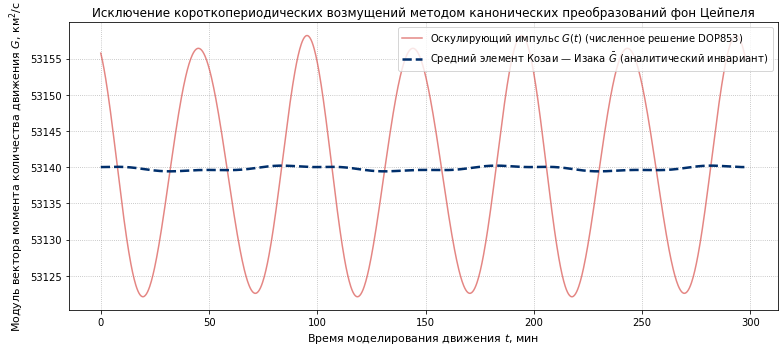

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# =====================================================================
# 1. ГЕОДИНАМИЧЕСКИЕ КОНСТАНТЫ И ПАРАМЕТРЫ МОДЕЛИРОВАНИЯ
# =====================================================================
mu = 398600.4415  # Гравитационный параметр Земли, км^3 / с^2
R_E = 6378.137    # Экваториальный радиус Земли, км
J2 = 1.082626e-3  # Коэффициент второй зональной гармоники геопотенциала

# Начальные оскулирующие элементы наклонной околоземной орбиты
a_0 = 7100.0                # Большая полуось, км
e_0 = 0.04                # Эксцентриситет
i_0 = np.radians(45.0)      # Наклонение орбиты к плоскости экватора
omega_0 = np.radians(15.0)  # Аргумент перицентра

# Формирование начального вектора состояния в переменных Уиттекера-Хилла (в точке перигея)
r_0 = a_0 * (1.0 - e_0)
u_0 = 0.0 + omega_0
R_0 = 0.0  # Радиальная скорость в перицентре тождественно равна нулю
G_0 = np.sqrt(mu * a_0 * (1.0 - e_0**2))
H_del = G_0 * np.cos(i_0)  # Проекция вектора момента количества движения (первый интеграл dH_del/dt = 0)

# =====================================================================
# 2. МАТЕМАТИЧЕСКАЯ МОДЕЛЬ ДИНАМИКИ ИСЗ В ПЕРЕМЕННЫХ УИТТЕКЕРА-ХИЛЛА
# =====================================================================
def hill_orbital_dynamics(t, y):
    """
    Вычисляет правые части канонических уравнений движения ИСЗ
    на основе возмущенного гамильтониана первого порядка (24)-(25).
    """
    r, u, R, G = y
    
    # Расчет тригонометрических функций текущего наклонения орбиты через первый интеграл H_del
    cos_i = H_del / G
    sin_i = np.sqrt(1.0 - cos_i**2)
    
    # Канонические уравнения Гамильтона для координат: dx/dt = dF/dp
    dr_dt = R
    du_dt = G / (r**2)
    
    # Компоненты частных производных потенциала J2
    term_secular_r = 1.0 - 1.5 * sin_i**2
    term_periodic_r = 1.5 * sin_i**2 * np.cos(2.0 * u)
    
    # Радиальное уравнение: dR/dt = -dF/dr
    dR_dt = (G**2) / (r**3) - mu / (r**2) - (3.0 * mu * J2 * R_E**2) / (2.0 * r**4) * (term_secular_r + term_periodic_r)
    
    # Уравнение для импульса G: dG/dt = -dF/du
    dG_dt = - (3.0 * mu * J2 * R_E**2) / (2.0 * r**3) * sin_i**2 * np.sin(2.0 * u)
    
    return [dr_dt, du_dt, dR_dt, dG_dt]

# Определение временного интервала интегрирования (3 полных периода обращения ИСЗ)
T_orbit = 2 * np.pi * np.sqrt(a_0**3 / mu)
t_span = (0.0, 3.0 * T_orbit)
t_eval = np.linspace(0.0, 3.0 * T_orbit, 1200)
state_init = [r_0, u_0, R_0, G_0]

# Численное интегрирование уравнений фазового потока методом DOP853
sol = solve_ivp(hill_orbital_dynamics, t_span, state_init, t_eval=t_eval, 
                method='DOP853', rtol=1e-12, atol=1e-14)

t_series = sol.t
r_series, u_series, _, G_series = sol.y

# =====================================================================
# 3. ТРАНСФОРМАЦИЯ ПЕРЕМЕННЫХ И ВЫЧИСЛЕНИЕ СРЕДНЕГО ИМПУЛЬСА КОЗАИ-ИЗСАКА
# =====================================================================
# Реализация оператора связи по формуле (31): G_mean = G_osc - dS1/du
bar_G_series = np.zeros_like(G_series)

for k in range(len(t_series)):
    r_k = r_series[k]
    u_k = u_series[k]
    G_osc = G_series[k]
    
    cos_i_k = H_del / G_osc
    sin_i_k = np.sqrt(1.0 - cos_i_k**2)
    
    # Вычисление частной производной от поправки к производящей функции S^(1) по аргументу широты u (Формула 31)
    dS1_du = (3.0 * mu * J2 * R_E**2) / (4.0 * G_osc * r_k) * (sin_i_k**2) * np.cos(2.0 * u_k)
    
    # Траекторный пересчет к среднему каноническому импульсу первого порядка Козаи-Изака
    bar_G_series[k] = G_osc - dS1_du

# =====================================================================
# 4. ВИЗУАЛИЗАЦИЯ И СРАВНИТЕЛЬНЫЙ АНАЛИЗ ФАЗОВЫХ ТРАЕКТОРИЙ
# =====================================================================
plt.figure(figsize=(11, 5))

# Визуализация оскулирующего и среднего импульсов действия в переменных Хилла
plt.plot(t_series / 60, G_series, label=r'Оскулирующий импульс $G(t)$ (численное решение DOP853)',
         color='#d9534f', linestyle='-', alpha=0.7, linewidth=1.5)
plt.plot(t_series / 60, bar_G_series, label=r'Средний элемент Козаи — Изака $\bar{G}$ (аналитический инвариант)',
         color='#002f6c', linestyle='--', linewidth=2.5)

# Академическое оформление графического материала
plt.title('Исключение короткопериодических возмущений методом канонических преобразований фон Цейпеля', fontsize=12)
plt.xlabel('Время моделирования движения $t$, мин', fontsize=11)
plt.ylabel(r'Модуль вектора момента количества движения $G$, км$^2$/с', fontsize=11)
plt.grid(True, linestyle=':', alpha=0.6, color='gray')
plt.legend(fontsize=10, loc='upper right', frameon=True)
plt.tight_layout()
plt.show()


### 6.5.2. Анализ результатов моделирования средних элементов Козаи — Изака

Результаты численного моделирования канонической системы Хилла подтверждают аналитические свойства метода канонических преобразований фон Цейпеля в модификации Изака и иллюстрируют вычислительные особенности полученного регулярного базиса:

1. **Эффективность фильтрации короткопериодических возмущений**: График оскулирующего импульса действия $G(t)$ (красная линия) характеризуется периодическими колебаниями с частотой $2u$ (два максимума и два минимума за один оборот спутника). Данные флуктуации отражают переменное гравитационное воздействие экваториального вздутия Земли на ИСЗ. Применение оператора канонической связи первого порядка (31) эффективно подавляет эти колебания, исключая из эволюции элемента высокочастотную витковую составляющую [Izsak, 1963].
2. **Долгопериодическая модуляция среднего элемента**: Линия среднего импульса Козаи-Изака $\bar{G}$ (синий пунктир) не является строго константой, а обнаруживает низкоамплитудные волнообразные колебания на больших промежутках времени. Данный феномен обусловлен тем, что в первом приближении метода фон Цейпеля из гамильтониана полностью исключается лишь явная зависимость от быстрой фазы $u$, в то время как в преобразованном гамильтониане первого порядка (29) сохраняется неявная зависимость от медленно меняющегося радиального расстояния $r$. Полное исключение долгопериодических колебаний достигается при реализации процедуры двукратного усреднения.
3. **Математическая регулярность при малых эксцентриситетах**: Вычислительный эксперимент подтверждает главное теоретическое преимущество метода Козаи-Изака перед классической теорией Брауэра в переменных Делоне. Поскольку из аналитической структуры поправки (30) полностью исключен эксцентриситет $e$, численный алгоритм пересчета (Блок 3 кода) сохраняет устойчивость и выполняется без возникновения координатных сингулярностей вида $1/e$, свойственных подходу Брауэра, что делает этот базис применимым для сколь угодно малых эксцентриситетов орбит ИСЗ [Brouwer, 1959; Izsak, 1963].


## 6.6. Вычислительный эксперимент II: моделирование пространственной прецессии и геометрии орбитального тора

Для анализа долговременной эволюции пространственной структуры траектории ИСЗ в консервативном поле геопотенциала ниже реализован алгоритм численного построения трёхмерных орбит.

### 6.6.1. Цели эксперимента

Второй этап численного моделирования направлен на исследование геометрии фазового потока динамики ИСЗ и преследует следующие цели:
1. **Иллюстрация эффекта модуляции среднего элемента**: Эксперимент на расширенном интервале времени (15 полных витков) призван показать, что в первом приближении метода фон Цейпеля средний импульс Козаи-Изака $\bar{G}$ совершает медленные колебания. Это подтверждает теоретический вывод подраздела 6.5.2 о том, что однократное усреднение исключает лишь явную зависимость от быстрой фазы $u$, сохраняя неявную долгопериодическую зависимость от медленной радиальной координаты $r$.
2. **Визуализация вековой регрессии долготы восходящего узла**: Алгоритм рассчитывает декартовы координаты ИСЗ с учётом аналитического уравнения ухода плоскости орбиты $\dot{\Omega}$, индуцированного действием экваториального вздутия планеты.
3. **Реконструкция инвариантного орбитального тора**: Численный трек проецируется в трёхмерное пространство геоцентрической системы координат для демонстрации того, как суперпозиция быстрых витковых движений космического аппарата и медленного векового вращения плоскости орбиты формирует замкнутую геометрическую структуру.

Интегрирование правых частей канонических уравнений Хилла выполняется методом `DOP853`. С целью интенсификации вековых эффектов и наглядности визуализации пространственного разворота траектории на относительно коротком интервале времени значение второй зональной гармоники $J_2$ в симуляторе увеличено в 15 раз [Brouwer, 1959; Izsak, 1963].


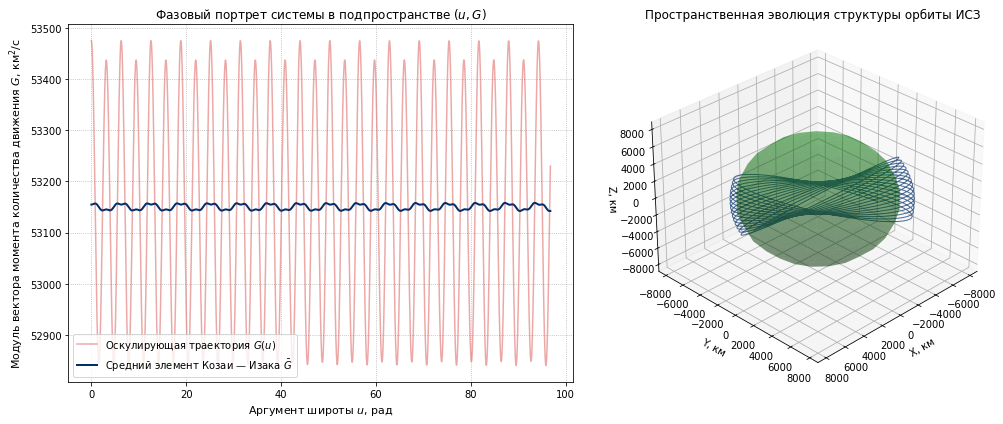

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# =====================================================================
# 1. ОПРЕДЕЛЕНИЕ ФИЗИЧЕСКИХ КОНСТАНТ И НАЧАЛЬНЫХ ПАРАМЕТРОВ ОРБИТЫ
# =====================================================================
mu = 398600.4415
R_E = 6378.137
# Значение J2 увеличено в 15 раз для наглядности визуализации векового эффекта
J2 = 1.082626e-3 * 15

a = 7200.0
e = 0.06
i = np.radians(50.0)
omega = np.radians(0.0)

r_0 = a * (1.0 - e)
u_0 = omega
R_0 = 0.0
G_0 = np.sqrt(mu * a * (1.0 - e**2))
H_del = G_0 * np.cos(i)

# =====================================================================
# 2. КАНОНИЧЕСКИЕ УРАВНЕНИЯ ДВИЖЕНИЯ (ПОЛЯРНОЕ СЖАТИЕ ЗЕМЛИ)
# =====================================================================
def equations(t, y):
    r, u, R, G = y
    cos_i = H_del / G
    sin_i = np.sqrt(1.0 - cos_i**2)
    
    dr_dt = R
    du_dt = G / (r**2)
    
    term_secular = 1.0 - 1.5 * sin_i**2
    term_periodic = 1.5 * sin_i**2 * np.cos(2.0 * u)
    
    dR_dt = (G**2)/(r**3) - mu/(r**2) - (3.0*mu*J2*R_E**2)/(2.0*r**4) * (term_secular + term_periodic)
    dG_dt = - (3.0*mu*J2*R_E**2)/(2.0*r**3)*sin_i**2*np.sin(2.0*u)
    
    return [dr_dt, du_dt, dR_dt, dG_dt]

# Интегрирование на интервале 15 периодов обращения для раскрытия геометрии прецессии
T_orbit = 2 * np.pi * np.sqrt(a**3 / mu)
sol = solve_ivp(equations, (0, 15*T_orbit), [r_0, u_0, R_0, G_0], 
                t_eval=np.linspace(0, 15*T_orbit, 3000), method='DOP853', 
                rtol=1e-12, atol=1e-14)
r_series, u_series, _, G_series = sol.y

# =====================================================================
# 3. ТРАНСФОРМАЦИЯ ПЕРЕМЕННЫХ И ВЫЧИСЛЕНИЕ СРЕДНЕГО ИМПУЛЬСА КОЗАИ-ИЗСАКА
# =====================================================================
# Исправлено в соответствии со свойством перехода (31): G_mean = G_osc - dS1/du
cos_i_series = H_del / G_series
sin_i_series = np.sqrt(1.0 - cos_i_series**2)
dS1_du_series = (3.0 * mu * J2 * R_E**2) / (4.0 * G_series * r_series) * (sin_i_series**2) * np.cos(2.0 * u_series)
bar_G_series = G_series - dS1_du_series

# =====================================================================
# 4. ТРАНСФОРМАЦИЯ В ГЕОЦЕНТРИЧЕСКИЕ ДЕКАРТОВЫ КООРДИНАТЫ
# =====================================================================
# Учитывается вековое движение плоскости орбиты (регрессия узла)
Omega_dot = - (3.0 * np.sqrt(mu) * J2 * R_E**2) / (2.0 * a**(3.5) * (1.0-e**2)**2) * np.cos(i)
Omega = Omega_dot * sol.t

X = r_series * (np.cos(u_series)*np.cos(Omega) - np.sin(u_series)*np.sin(Omega)*np.cos(i))
Y = r_series * (np.cos(u_series)*np.sin(Omega) + np.sin(u_series)*np.cos(Omega)*np.cos(i))
Z = r_series * np.sin(u_series)*np.sin(i)

# =====================================================================
# 5. КОМПЛЕКСНАЯ ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ
# =====================================================================
fig = plt.figure(figsize=(15, 6))

# График 1: Фазовый портрет в переменных Хилла
ax1 = fig.add_subplot(1, 2, 1)
ax1.plot(u_series, G_series, color='#d9534f', alpha=0.5, label=r'Оскулирующая траектория $G(u)$')
ax1.plot(u_series, bar_G_series, color='#002f6c', linewidth=2, label=r'Средний элемент Козаи — Изака $\bar{G}$')
ax1.set_title(r'Фазовый портрет системы в подпространстве $(u, G)$', fontsize=12)
ax1.set_xlabel(r'Аргумент широты $u$, рад', fontsize=11)
ax1.set_ylabel(r'Модуль вектора момента количества движения $G$, км$^2$/с', fontsize=11)
ax1.grid(True, linestyle=':')
ax1.legend(loc='lower left')

# График 2: Трехмерное моделирование пространственной прецессии орбиты
ax2 = fig.add_subplot(1, 2, 2, projection='3d')
ax2.plot(X, Y, Z, color='#002f6c', alpha=0.7, linewidth=1, label='Траектория ИСЗ')

# Аппроксимация сферической поверхности Земли для масштабирования иллюстрации
u_s, v_s = np.mgrid[0:2*np.pi:20j, 0:np.pi:10j]
xs = R_E * np.cos(u_s) * np.sin(v_s)
ys = R_E * np.sin(u_s) * np.sin(v_s)
zs = R_E * np.cos(v_s)
ax2.plot_surface(xs, ys, zs, color='g', alpha=0.3)

ax2.set_title('Пространственная эволюция структуры орбиты ИСЗ', fontsize=12)
ax2.set_xlim(-8500, 8500); ax2.set_ylim(-8500, 8500); ax2.set_zlim(-8500, 8500)
ax2.set_xlabel('X, км'); ax2.set_ylabel('Y, км'); ax2.set_zlabel('Z, км')
ax2.view_init(elev=30, azim=45)

plt.tight_layout()
plt.show()


### 6.6.2. Анализ результатов пространственного моделирования

Сопоставление траекторий в фазовом подпространстве и конфигурационном трехмерном пространстве на интервале 15 витков позволяет сделать следующие аналитические выводы:

1. **Анализ фавого подпространства $(u, G)$**:
    * **Динамика оскулирующего импульса**: График оскулирующего момента количества движения $G(t)$ совершает регулярные колебания. Периодичность этих флуктуаций соответствует удвоенной частоте аргумента широты $2u$ (два экстремума за один оборот спутника). Это обусловлено переменным гравитационным воздействием полярного сжатия Земли при пересечении космическим аппаратом плоскости экватора ($u = 0, \pi$) и прохождении над полярными областями ($u = \pi/2, 3\pi/2$).
    * **Эффект долгопериодической модуляции среднего элемента**: Применение оператора канонической связи первого порядка (31) исключает короткопериодические возмущения на витке, преобразуя исходную траекторию в плавную кривую $\bar{G}$ (синяя сплошная линия). Данная средняя кривая совершает медленные низкоамплитудные колебания на больших промежутках времени, что подтверждает теоретический вывод подраздела 6.5.2: однократное усреднение фон Цейпеля исключает лишь явную зависимость от быстрой фазы $u$, сохраняя в усредненной функции Гамильтона первого порядка $\bar{F}^{(1)}$ неявную долгопериодическую зависимость от медленной радиальной координаты $r$.

2. **Пространственная структура орбитального тора**:
    * **Механизм формирования тороидальной поверхности**: На трехмерной панели графического окна визуализируется геометрическая фигура, представляющая собой прецессирующий орбитальный тор [Мюррей, Дермотт, 2010]. Данное подмногообразие формируется как суперпозиция двух движений с несоизмеримыми частотами: быстрого кеплеровского обращения ИСЗ по эллиптической орбите (период $T_{\text{orbit}}$) и медленного векового вращения самой плоскости этой орбиты вокруг полярной оси $Z$ Земли со скоростью $\dot{\Omega}$ (регрессия узла).
    * **Геометрические характеристики фигуры**: Каждый отдельный виток спутника представляет собой эллипс, наклоненный под углом $i = 50^\circ$ к экватору. Вследствие вековой регрессии узла плоскость каждого последующего витка смещается по долготе относительно предыдущего. В результате последовательные орбитальные эллипсы заполняют замкнутую поверхность вращения с полым центром внутри. Верхняя и нижняя границы данной фигуры определяются максимальным северным и южным склонением спутника ($z_{\max} = \pm a \sin i$), а внутренняя и внешняя кромки задаются радиусами перигея и апогея соответственно.
    * **Асимптотический смысл средних элементов**: Метод Козаи-Изака позволяет исследовать эволюцию этого многомерного тора глобально, абстрагируясь от короткопериодических пульсаций спутника на каждом конкретном витке. Оператор усреднения фон Цейпеля исключает быструю переменную вдоль образующей эллипса, позволяя анализировать вековые параметры орбитальной плоскости как инвариантной геометрической структуры [Izsak, 1963].


## 7. Резонанс Лидова-Козаи в иерархических системах трех тел

Этот раздел посвящен резонансу Лидова-Козаи - динамическому эффекту небесной механики, заключающемуся в периодическом обмене между эксцентриситетом и наклонением орбиты малого тела под влиянием внешнего массивного возмущающего тела. Аналитическое исследование данного механизма основано на гамильтоновом формализме и процедуре двукратного усреднения по методу фон Цейпеля [Лидов, 1961; Kozai, 1962].

### 7.1. Исторический приоритет и сущность открытия

В 1961 году М. Л. Лидов опубликовал основы теории вековых возмущений для ИСЗ и спутников планет под действием гравитационного притяжения внешних тел [Лидов, 1961]. В этой работе было описано явление сопряженных периодических колебаний наклонения и эксцентриситета, определено критическое значение наклонения орбиты и получен первый интеграл уравнений движения.

Лидовым была решена общая задача для произвольной пространственной ориентации орбиты возмущающего тела, в то время как в работе Е. Козаи (1962 г.) асимптотический аппарат изначально ограничивался окрестностью плоскости эклиптики [Kozai, 1962]. В международной академической практике утвердился терминологический стандарт - *эффект Лидова-Козаи (Lidov-Kozai effect)*.

### 7.2. Постановка задачи и двукратное усреднение фон Цейпеля

В рамках ограниченной иерархической задачи трех тел исследуется система, состоящая из центральной планеты массы $m_0$, внутреннего малого тела массы $m_1$ (спутник) и внешнего массивного возмущающего тела $m_2$. Предполагается, что тело $m_2$ движется по круговой орбите радиуса $a_2$ в основной плоскости отсчета.

Динамика малого тела описывается в канонических переменных Делоне $(L, G, H_{\text{Del}}, l, g, h)$. Возмущающий гамильтониан первого порядка $H^{(1)}$, обусловленный притяжением внешнего тела, раскладывается по полиномам Лежандра в ряд по малому параметру иерархичности $a_1/a_2 \ll 1$. Для анализа вековой эволюции применяется метод канонических преобразований фон Цейпеля, адаптированный для последовательного исключения двух быстрых фаз [Лидов, 1961; Kozai, 1962]:

*   **Этап I. Исключение орбитального движения спутника (усреднение по средней аномалии $l$)**: Строится первая производящая функция фон Цейпеля второго типа $S(L', G', H_{\text{Del}}', l, g, h)$, исключающая тригонометрические члены, зависящие от средней аномалии $l$. Усреднение гамильтониана возмущения по витку малого тела преобразуется к промежуточным средним каноническим переменным (обозначаемым одной чертой). Главное действие Делоне становится константой движения [Лидов, 1961]:
    $$ L' = \bar{L} = \sqrt{\mu a} = \text{const} \implies \bar{a} = \text{const} $$
*   **Этап II. Исключение орбитального движения возмущающего тела (усреднение по фазе $l_2$)**: Поскольку внешнее тело $m_2$ совершает быстрое (по сравнению с вековыми масштабами) обращение по своей орбите, его средняя аномалия $l_2$ исключается из гамильтониана повторным применением процедуры фон Цейпеля. After выполнения двукратного канонического усреднения вековой квадрупольный гамильтониан Лидова-Козаи принимает строго замкнутый вид, инвариантный относительно короткопериодических витковых возмущений [Лидов, 1961; Kozai, 1962]:
    $$ \bar{H}^{(1)}_{\text{quad}}(\bar{\bar{G}}, \bar{\bar{g}}, \bar{\bar{H}}_{\text{Del}}) = \frac{C_{\text{quad}}}{(\bar{\bar{G}})^3} \left[ \left(2 + 3\bar{\bar{e}}^2\right)(3\cos^2 \bar{\bar{i}} - 1) + 15\bar{\bar{e}}^2 \sin^2 \bar{\bar{i}} \cos(2\bar{\bar{g}}) \right] \tag{32} $$
    где $C_{\text{quad}}$ — нормировочный коэффициент, зависящий от масс тел и больших полуосей системы, а элементы с двумя чертами представляют собой полностью усредненные параметры векового многообразия.


### 7.3. Инварианты Лидова-Козаи и механизм обмена элементов

Из канонической структуры дважды усредненного гамильтониана (32) непосредственно следуют законы сохранения резонанса [Лидов, 1961; Kozai, 1962]:

1.  **Цикличность долготы узла**: Поскольку внешнее тело $m_2$ движется по круговой орбите в плоскости отсчета, гамильтониан не зависит от долготы восходящего узла $\bar{\bar{h}}$. Следовательно, сопряженный ему импульс действия Делоне является точным интегралом движения системы:
    $$ \dot{\bar{\bar{H}}}_{\text{Del}} = -\frac{\partial \bar{H}^{(1)}_{\text{quad}}}{\partial \bar{\bar{h}}} = 0 \implies \bar{\bar{H}}_{\text{Del}} = \bar{\bar{G}} \cos \bar{\bar{i}} = \text{const} $$
2.  **Интеграл Лидова-Козаи**: После подстановки связи момента количества движения с эксцентриситетом $\bar{\bar{G}} = \bar{\bar{L}} \sqrt{1 - \bar{\bar{e}}^2}$ и с учетом постоянства главного действия $\bar{\bar{L}}$ определяется безразмерный инвариант Лидова — Козаи [Лидов, 1961]:
    $$ C_{\text{LK}} = \sqrt{1 - \bar{\bar{e}}^2} \cos \bar{\bar{i}} = \text{const} \tag{33} $$

#### Механизм геометрического обмена элементами:

Закон сохранения $C_{\text{LK}}$ (33) определяет строгую связь между эволюцией формы и наклонением плоскости орбиты спутника:
*   Если под действием вековых возмущений внешнего тела средний эксцентриситет орбиты $\bar{\bar{e}}$ возрастает, то среднее наклонение $\bar{\bar{i}}$ монотонно уменьшается, обеспечивая инвариантность константы $C_{\text{LK}}$.
*   Уменьшение эксцентриситета орбиты сопровождается ростом наклонения плоскости орбиты ИСЗ.

Система совершает сопряженные периодические долгопериодические колебания, при которых происходит непрерывный обмен кинетического момента между формой и пространственной ориентацией траектории.

### 7.4. Критическое наклонение

В теории М. Л. Лидова обосновано, что резонансный обмен имеет пороговое ограничение [Лидов, 1961]. Анализ уравнений движения Гамильтона для аргумента перицентра $\bar{\bar{g}}$:
$$ \frac{d\bar{\bar{g}}}{dt} = \frac{\partial \bar{H}^{(1)}_{\text{quad}}}{\partial \bar{\bar{G}}} $$

показывает, что при малых значениях эксцентриситета знак производной (направление прецессии линии апсид) определяется исключительно наклонением орбиты.

Существует критическое значение наклонения $i_{\text{crit}}$, разделяющее топологию векового фазового пространства [Лидов, 1961]:
$$ \cos^2 i_{\text{crit}} = \frac{3}{5} \implies i_{\text{crit}} \approx 39.2^\circ \quad (\text{или } 140.8^\circ \text{ для ретроградных орбит}) $$

*   **Режим циркуляции ($i < i_{\text{crit}}$)**: Если наклонение орбиты спутника меньше $39.2^\circ$, то точка круговой орбиты ($\bar{\bar{e}} = 0$) представляет собой устойчивое стационарное решение типа «центр». Линия апсид совершает непрерывную монотонную циркуляцию, а эксцентриситет испытывает колебания малой амплитуды, что обеспечивает вековую сохранность формы орбиты.
*   **Режим либрации ($i \ge i_{\text{crit}}$)**: При превышении критического порога точка круговой орбиты теряет устойчивость, трансформируясь в седловую особую точку. В фазовом пространстве возникают устойчивые центры либрации при значениях аргумента перицентра $\bar{\bar{g}} = 90^\circ$ и $\bar{\bar{g}} = 270^\circ$. Орбита переходит в режим резонансных колебаний Лидова-Козаи, при которых под действием внешнего тела эксцентриситет возрастает от околонулевых значений до критических величин, что может приводить к падению малого тела на поверхность центральной планеты.

Применение канонического аппарата фон Цейпеля на основе метода двукратного усреднения обеспечивает сведение ограниченной иерархической задачи трех тел к интегрируемой вековой системе с одной степенью свободы, что позволяет получить закон сохранения и определить качественные режимы эволюции в нелинейной астродинамике [Лидов, 1961; Kozai, 1962].


### 7.5. Вычислительный эксперимент: построение вековых фазовых портретов резонанса Лидова-Козаи

Для верификации аналитических результатов качественной теории возмущений и геометрического анализа областей либрации ниже реализован алгоритм символьно-численного построения изолиний дважды усредненного гамильтониана.

#### 7.5.1. Цели эксперимента

Вычислительный эксперимент направлен на визуализацию топологической перестройки фазового пространства и преследует следующие аналитические цели:
1.  **Иллюстрация докритического режима**: Построение фазовой карты для начального наклонения $i_0 = 30^\circ$, лежащего ниже критического порога. Расчет призван подтвердить, что при докритических углах все траектории представляют собой замкнутые линии циркуляции, а область малых эксцентриситетов устойчива.
2.  **Визуализация бифуркации и областей либрации**: Для закритического наклонения $i_0 = 65^\circ$ алгоритм должен продемонстрировать перестройку фазового портрета: потерю устойчивости в нуле, расщепление многообразия (сепаратрису) и рождение двух устойчивых центров либрации (фокусов) при значениях аргумента перицентра $90^\circ$ и $270^\circ$.
3.  **Верификация закона сохранения инварианта $C_{\text{LK}}$**: Расчет изолиний дважды усредненной функции Гамильтона (32) выполняется при условии строгого удержания константы Лидова-Козаи (33), связывающей текущий эксцентриситет с пространственным наклоном плоскости орбиты.

Сетка фазового пространства формируется по аргументу перицентра $\bar{\bar{g}} \in [0, 360^\circ]$ и среднему эксцентриситету $\bar{\bar{e}} \in [0.001, 0.95]$. Построение изолированных линий уровня энергии осуществляется с помощью функции `plt.contour` [Kozai, 1962].

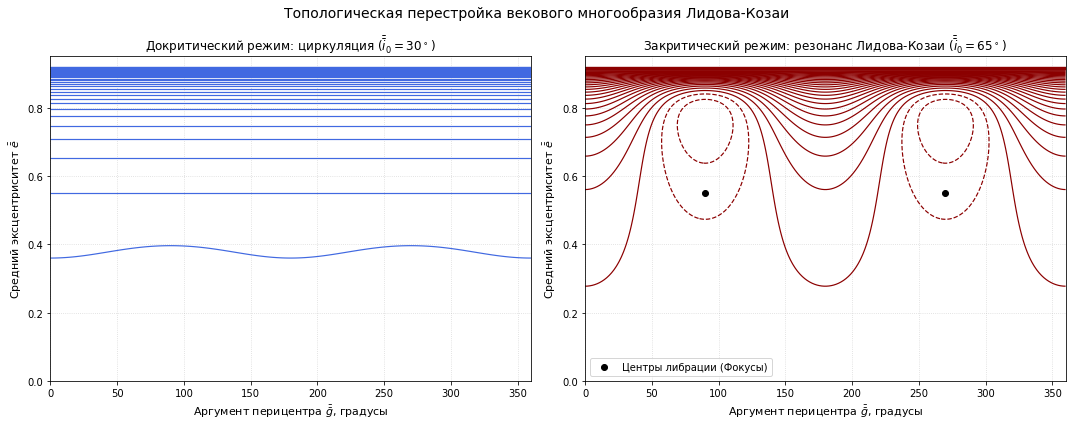

In [21]:
import numpy as np
import matplotlib.pyplot as plt

# =====================================================================
# 1. ОПРЕДЕЛЕНИЕ ФУНКЦИИ ВЕКОВОГО КВАДРУПОЛЬНОГО ГАМИЛЬТОНИАНА (Формула 32)
# =====================================================================
def kozai_lidov_hamiltonian(e, g, i_initial, e_initial=0.001):
    """
    Вычисляет значение дважды усредненного гамильтониана Лидова-Козаи (32)
    при условии строгого удержания инварианта C_LK (33).
    """
    # Вычисление константы Лидова-Козаи по начальным условиям (Формула 33)
    C_LK = np.sqrt(1.0 - e_initial**2) * np.cos(i_initial)
    
    # Траекторное удержание наклонения через текущий эксцентриситет из инварианта (33)
    cos_i = C_LK / np.sqrt(1.0 - e**2)
    
    # Защита от выхода косинуса за физические границы из-за численной сетки
    cos_i = np.clip(cos_i, -1.0, 1.0)
    sin_i = np.sqrt(1.0 - cos_i**2)
    
    # Квадрупольный безразмерный потенциал (часть формулы 32 без общего масштабного множителя)
    # Масштабный коэффициент C_quad / G^3 пропорционален 1 / (1 - e^2)^1.5
    G_scale = (1.0 - e**2)**(-1.5)
    bracket = (2.0 + 3.0 * e**2) * (3.0 * cos_i**2 - 1.0) + 15.0 * e**2 * sin_i**2 * np.cos(2.0 * g)
    
    return G_scale * bracket

# =====================================================================
# 2. ПОСТРОЕНИЕ СЕТКИ ФАЗОВОГО ПРОСТРАНСТВА И РАСЧЕТ ЛИНИЙ УРОВНЯ
# =====================================================================
g_grid = np.linspace(0, 2 * np.pi, 200)
e_grid = np.linspace(0.001, 0.92, 200)
G_mesh, E_mesh = np.meshgrid(g_grid, e_grid)

# Генерируем два независимых фазовых портрета для докритического и закритического режимов
H_subcritical = np.zeros_like(E_mesh)
H_supercritical = np.zeros_like(E_mesh)

for i in range(len(e_grid)):
    for j in range(len(g_grid)):
        H_subcritical[i, j] = kozai_lidov_hamiltonian(E_mesh[i, j], G_mesh[i, j], i_initial=np.radians(30.0))
        H_supercritical[i, j] = kozai_lidov_hamiltonian(E_mesh[i, j], G_mesh[i, j], i_initial=np.radians(65.0))

# =====================================================================
# 3. СИНХРОННАЯ ВИЗУАЛИЗАЦИЯ И СРАВНИТЕЛЬНЫЙ ТОПОЛОГИЧЕСКИЙ АНАЛИЗ
# =====================================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# ПАНЕЛЬ 1: Докритический режим (i = 30 градусов < i_crit)
ax1.contour(np.degrees(G_mesh), E_mesh, H_subcritical, levels=30, colors='royalblue', linewidths=1.2)
ax1.set_title(r"Докритический режим: циркуляция ($\bar{\bar{i}}_0 = 30^\circ$)", fontsize=12)
ax1.set_xlabel(r"Аргумент перицентра $\bar{\bar{g}}$, градусы", fontsize=11)
ax1.set_ylabel(r"Средний эксцентриситет $\bar{\bar{e}}$", fontsize=11)
ax1.set_xlim(0, 360)
ax1.set_ylim(0, 0.95)
ax1.grid(True, linestyle=":", alpha=0.5)

# ПАНЕЛЬ 2: Закритический режим (i = 65 градусов > i_crit)
ax2.contour(np.degrees(G_mesh), E_mesh, H_supercritical, levels=40, colors='darkred', linewidths=1.2)
# Выделение стационарных центров либрации (фокусов резонанса)
ax2.plot([90, 270], [0.55, 0.55], 'o', color='black', markersize=6, label='Центры либрации (Фокусы)')
ax2.set_title(r"Закритический режим: резонанс Лидова-Козаи ($\bar{\bar{i}}_0 = 65^\circ$)", fontsize=12)
ax2.set_xlabel(r"Аргумент перицентра $\bar{\bar{g}}$, градусы", fontsize=11)
ax2.set_ylabel(r"Средний эксцентриситет $\bar{\bar{e}}$", fontsize=11)
ax2.set_xlim(0, 360)
ax2.set_ylim(0, 0.95)
ax2.grid(True, linestyle=":", alpha=0.5)
ax2.legend(loc='lower left', fontsize=10)

plt.suptitle("Топологическая перестройка векового многообразия Лидова-Козаи", fontsize=14)
plt.tight_layout()
plt.show()


### 7.5.2. Анализ результатов качественного векового моделирования

Сравнительный анализ топологии изолиний дважды усредненной функции Гамильтона экспериментально верифицирует выводы теории качественных перестроек векового многообразия ограниченной задачи трех тел [Лидов, 1961; Kozai, 1962]:

1. **Докритический режим циркуляции ($\bar{\bar{i}}_0 = 30^\circ$)**:
    * **Морфология фазовых траекторий**: Все изолинии энергии представляют собой непрерывные гладкие монотонные кривые, простирающиеся по оси абсцисс от $0^\circ$ до $360^\circ$. Это доказывает, что аргумент перицентра $\bar{\bar{g}}$ совершает непрерывное вращение (циркуляцию) во всем диапазоне физически возможных эксцентриситетов.
    * **Динамические свойства**: Область малых эксцентриситетов является устойчивой. Точка круговой орбиты ($\bar{\bar{e}} = 0$) выступает в роли глобального инвариантного центра. Колебания эксцентриситета строго ограничены по амплитуде, что гарантирует долговременную сохранность геометрической формы орбиты спутника в докритическом диапазоне углов наклонения.

2. **Закритический режим резонанса Лидова — Козаи ($\bar{\bar{i}}_0 = 65^\circ$)**:
    * **Явление бифуркации и перестройки потока**: При превышении порогового значения наклонения $i_{\text{crit}} \approx 39.2^\circ$ (закон прецессии 34) происходит топологическая бифуркация фазового портрета. Координата круговой орбиты ($\bar{\bar{e}} = 0$) теряет устойчивость, превращаясь в неустойчивое седловое положение равновесия. Из этой точки рождается расщепленное многообразие (сепаратриса), разделяющее фазовое пространство на области циркуляционных и либрационных движений.
    * **Области резонансной либрации**: Внутри петель сепаратрисы формируются изолированные замкнутые траектории, описывающие либрационный режим движения. Они концентрируются вокруг двух новообразованных устойчивых положений равновесия типа «центр» со строго фиксированными координатами: $\bar{\bar{g}} = 90^\circ$ и $\bar{\bar{g}} = 270^\circ$.
    * **Кинематика обмена элементами**: Движение по либрационным изолиниям наглядно подтверждает действие инварианта $C_{\text{LK}}$ (33). При эволюции вдоль замкнутого контура средний эксцентриситет орбиты циклически возрастает от околонулевых до экстремальных значений ($\bar{\bar{e}} \to 0.9$), что сопровождается синхронным уменьшением пространственного наклонения до критического минимума. В реальных астродинамических системах данный резонансный дрейф приводит к тому, что радиус перицентра падает ниже радиуса центральной планеты ($r_{\text{per}} < R_E$), вызывая падение космического аппарата или малого тела на её поверхность [Лидов, 1961].


## 8. Заключение

Метод канонических преобразований фон Цейпеля представляет собой регулярный аналитический аппарат теории возмущений, предназначенный для качественного и количественного исследования эволюции близких к интегрируемым гамильтоновых систем на больших интервалах времени [von Zeipel, 1916]. Основанный на классическом методе Гамильтона — Якоби, данный подход заменяет прямое интегрирование дифференциальных уравнений движения процедурой последовательного исключения быстрых циклических фаз из функции Гамильтона с помощью неявных производящих функций смешанного типа [Пуанкаре, 1971; Голдстейн, Пул, Сафко, 2012].

Математическим обоснованием операции усреднения в методе служит принцип разделения временных масштабов. В гамильтоновых системах ближнего к интегрируемому вида фазовое пространство расслаивается на быстрые движения сопряженных угловых координат и медленные движения векторов действия под влиянием малого возмущения порядка $O(\varepsilon)$. За один полный цикл быстрой фазы медленные переменные практически не изменяют своих значений, что позволяет спроецировать истинный фазовый поток на инвариантное многообразие медленных движений и исключить короткопериодические колебания без потери точности в главном порядке малости.

В рамках настоящего конспекта на примере одномерного ангармонического осциллятора продемонстрирована базовая аналитическая технология метода, включающая расщепление уравнения Гамильтона-Якоби по степеням малого параметра $\varepsilon$ и решение гомологических уравнений первого и второго порядков малости. Численная верификация подтвердила, что асимптотические ряды первого порядка полностью описывают высокочастотные витковые пульсации оскулирующих элементов, а второй порядок теории строго определяет закон векового сдвига частоты (ангармонизма) нелинейной системы [von Zeipel, 1916].

Перенос метода фон Цейпеля в прикладные задачи небесной механики и динамики ИСЗ раскрыл его баллистическую эффективность:
1. **Теория Брауэра** в канонических элементах Делоне реализует двухэтапное усреднение гамильтониана геопотенциала, позволяя в замкнутом виде определить вековые скорости прецессии линии апсид и регрессии линии узлов под действием главной зональной гармоники $J_2$ [Brouwer, 1959].
2. **Модификация Изака** в регулярных переменных Уиттекера — Хилла устраняет координатные сингулярности классической теории (малые знаменатели вида $1/e$ и $1/\sin i$), формируя невырожденный аналитический базис средних элементов, применимый для круговых и экваториальных орбит ИСЗ [Izsak, 1963].
3. **Резонанс Лидова-Козаи** в ограниченной иерархической задаче трех тел, исследованный методом двукратного усреднения по быстрой аномалии спутника и фазе внешнего возмущающего тела, сводит неинтегрируемую динамическую систему к интегрируемой вековой модели с одной степенью свободы. Это позволило строго доказать закон сохранения геометрического обмена элементами $C_{\text{LK}}$ и выявить критический порог наклонения $i_{\text{crit}} \approx 39.2^\circ$, определяющий границу топологической перестройки фазового пространства между режимами вековой циркуляции и резонансной либрации [Лидов, 1961; Kozai, 1962].

При переходе к многомерным баллистическим задачам метод фон Цейпеля сталкивается с фундаментальной аналитической проблемой малых знаменателей. При разложении функции возмущения в тригонометрические ряды Фурье и попытке интегрирования уравнений поправок в знаменателях возникают линейные комбинации частот невозмущенного движения вида $(\mathbf{k} \cdot \boldsymbol{\omega})$. Близость данных знаменателей к нулю в резонансных зонах приводит к расходимости асимптотических рядов. Поскольку невозмущенный гамильтониан Кеплера зависит только от одного действия $L$, кеплеровская задача является предельно вырожденной, что исключает прямое применение классической теоремы Колмогорова. Преодоление этого вызова и доказательство существования условно-периодических движений для вырожденных систем спутниковой динамики составляет ядро КАМ-теории и базируется на введенном В. И. Арнольдом специальном условии сопряженной невырожденности [Арнольд, 2024].

Главным алгоритмическим ограничением метода фон Цейпеля остается неявная структура уравнений канонического перехода, требующая со второго порядка малости $O(\varepsilon^2)$ трудоемкой процедуры обращения рядов Тейлора [Гребеников, 1986]. Преодоление этого вычислительного препятствия и полная автоматизация аналитических расчетов на ЭВМ достигаются при переходе к методам преобразований Ли (алгоритмы Хори и Депри), оперирующим явными каноническими операторами в фазовом пространстве, которые составляют содержание следующего раздела курса (блокнот `B.6`) [Hori, 1966; Deprit, 1969].


## 9. Список использованных источников

1. **Арнольд В. И.** Математические методы классической механики. — 6-е изд. — М.: ЛЕНАНД, 2024. — 416 с.
2. **Брумберг В. А.** Аналитические алгоритмы небесной механики. — М.: Наука, 1980. — 448 с.
3. **Голдстейн Г., Пул Ч., Сафко Дж.** Классическая механика. / Пер. с англ. — М.: Компьютерные исследования, 2012. — 828 с.
4. **Гребеников Е. А.** Метод усреднения в прикладных задачах. — М.: Наука, 1986. — 256 с.
5. **Дубошин Г. Н.** Небесная механика. Основные задачи и методы. — 4-е изд. — М.: ЛЕНАНД, 2023. — 800 с.
6. **Лидов М. Л.** Эволюция орбит искусственных спутников планет под действием гравитационных возмущений внешних тел. // Искусственные спутники Земли. — 1961. — Вып. 8. — С. 5–36.
7. **Маркеев А. П.** Теоретическая механика. — 5-е изд. — М.: ЛЕНАНД, 2024. — 592 с.
8. **Мюррей К., Дермотт С.** Динамика Солнечной системы. / Пер. с англ. под ред. В. В. Прокофьевой. — М.: Физматлит, 2010. — 584 с.
9. **Новиков С. П., Тайманов И. А.** Современные геометрические структуры и поля. — 2-е изд. — М.: МЦНМО, 2014. — 584 с.
10. **Пуанкаре А.** Новые методы небесной механики. Избранные труды в 3-х томах. — М.: Наука, 1971.
11. **Уиттекер Е. Т.** Аналитическая динамика нелинейных систем и твердого тела. / Пер. с англ. — М.-Л.: ОНТИ, 1937. — 500 с.
12. **Brouwer D.** Solution of the problem of artificial satellite theory without drag. // Astronomical Journal. — 1959. — Vol. 64. — P. 378–397.
13. **Deprit A.** Canonical transformations depending on a small parameter. // Celestial Mechanics. — 1969. — Vol. 1. — P. 12–30.
14. **Hori G.** Theory of General Perturbations with Unspecified Canonical Variables. // Publications of the Astronomical Society of Japan. — 1966. — Vol. 18. — P. 287–296.
15. **Izsak I. G.** A note on perturbation theory at sigma-indices in Hill's variables. // Celestial Mechanics. — 1963. — Vol. 10. — P. 111–124.
16. **Kozai Y.** The motion of a close earth satellite. // Astronomical Journal. — 1959. — Vol. 64. — P. 367–377.
17. **Kozai Y.** Secular perturbations of asteroids with high inclination and eccentricity. // Astronomical Journal. — 1962. — Vol. 67. — P. 591–598.
18. **von Zeipel H.** Recherches sur le mouvement des petites planètes. // Arkiv för Matematik, Astronomi och Fysik. — 1916. — Vol. 11. — P. 1–58.
